In [1]:
import os
import pandas as pd

TRAIN_ROOT = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/ZhangLabData/CellData/OCT/train"
TEST_ROOT  = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/ZhangLabData/CellData/OCT/test"

CLASSES = ["NORMAL", "DRUSEN", "DME", "CNV"]
def count_images_per_class(root_dir, classes):
    data = []
    total = 0

    for cls in classes:
        cls_dir = os.path.join(root_dir, cls)
        if not os.path.exists(cls_dir):
            count = 0
        else:
            count = len([
                f for f in os.listdir(cls_dir)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ])
        data.append({"class": cls, "count": count})
        total += count

    df = pd.DataFrame(data)
    df["percentage"] = (df["count"] / total * 100).round(2)
    return df, total

train_df, train_total = count_images_per_class(TRAIN_ROOT, CLASSES)
test_df, test_total   = count_images_per_class(TEST_ROOT, CLASSES)

print("📊 TRAIN SET DISTRIBUTION")
print(train_df)
print(f"\nTotal train images: {train_total}")

print("\n" + "="*50 + "\n")

print("📊 TEST SET DISTRIBUTION")
print(test_df)
print(f"\nTotal test images: {test_total}")


📊 TRAIN SET DISTRIBUTION
    class  count  percentage
0  NORMAL  51140       47.22
1  DRUSEN   8616        7.96
2     DME  11348       10.48
3     CNV  37205       34.35

Total train images: 108309


📊 TEST SET DISTRIBUTION
    class  count  percentage
0  NORMAL    250        25.0
1  DRUSEN    250        25.0
2     DME    250        25.0
3     CNV    250        25.0

Total test images: 1000


In [7]:
import os
import pandas as pd

TRAIN_ROOT = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/ZhangLabData/CellData/OCT/train"
TEST_ROOT  = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/ZhangLabData/CellData/OCT/test"

LABEL_MAP = {
    "NORMAL":  0,
    "DRUSEN":  1,
    "DME":     2,
    "CNV":     3
}
def build_split_df(root_dir, split_name, label_map):
    rows = []

    for label_text, label_id in label_map.items():
        class_dir = os.path.join(root_dir, label_text)
        if not os.path.exists(class_dir):
            continue

        for fname in os.listdir(class_dir):
            if fname.lower().endswith(".jpeg"):
                full_path = os.path.join(class_dir, fname)

                rows.append({
                    "split": split_name,
                    "new_file_path": full_path,
                    "label_text": label_text,
                    "binary_label": label_id
                })

    return pd.DataFrame(rows)
    

train_df = build_split_df(TRAIN_ROOT, "train", LABEL_MAP)
test_df  = build_split_df(TEST_ROOT,  "test",  LABEL_MAP)
train_df = train_df.rename(columns={"binary_label": "four_class_label"})
test_df = test_df.rename(columns={"binary_label": "four_class_label"})

train_df["binary_label"] = (train_df["four_class_label"] != 0).astype(int)
test_df["binary_label"] = (test_df["four_class_label"] != 0).astype(int)

df = pd.concat([train_df, test_df], ignore_index=True)
print("Overall distribution:")
print(df["label_text"].value_counts())

print("\nTrain distribution:")
print(train_df["label_text"].value_counts())

print("\nTest distribution:")
print(test_df["label_text"].value_counts())
df.head()


Overall distribution:
label_text
NORMAL    51390
CNV       37455
DME       11598
DRUSEN     8866
Name: count, dtype: int64

Train distribution:
label_text
NORMAL    51140
CNV       37205
DME       11348
DRUSEN     8616
Name: count, dtype: int64

Test distribution:
label_text
NORMAL    250
DRUSEN    250
DME       250
CNV       250
Name: count, dtype: int64


,split,new_file_path,label_text,four_class_label,binary_label
0,train,/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...,NORMAL,0,0
1,train,/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...,NORMAL,0,0
2,train,/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...,NORMAL,0,0
3,train,/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...,NORMAL,0,0
4,train,/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...,NORMAL,0,0


In [8]:
df[["label_text", "four_class_label", "binary_label"]].drop_duplicates().sort_values("four_class_label")


,label_text,four_class_label,binary_label
0,NORMAL,0,0
51140,DRUSEN,1,1
59756,DME,2,1
71104,CNV,3,1


In [6]:
df['binary_label'].value_counts()

binary_label
0    51390
3    37455
2    11598
1     8866
Name: count, dtype: int64

In [9]:
train_df.to_csv("train_ucsd.csv", index=False)
test_df.to_csv("test_ucsd.csv", index=False)

In [10]:
df.to_csv("ucsd.csv", index=False)

In [11]:
import pandas as pd
import numpy as np
from pathlib import Path

TRAIN_CSV = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/train_ucsd.csv"

train_df = pd.read_csv(TRAIN_CSV)
def extract_patient_id(path):
    fname = Path(path).name              # e.g. DME-1569-1.jpeg
    parts = fname.replace(".jpeg", "").split("-")
    return parts[1]                      # patient ID
train_df["patient_id"] = train_df["new_file_path"].apply(extract_patient_id)
VAL_TARGET_PER_CLASS = 250
RANDOM_SEED = 42

val_patient_ids = set()

rng = np.random.default_rng(RANDOM_SEED)

for label in ["NORMAL", "DRUSEN", "DME", "CNV"]:
    class_df = train_df[train_df["label_text"] == label]

    # group by patient
    patient_groups = (
        class_df.groupby("patient_id")
        .size()
        .reset_index(name="num_images")
    )

    # shuffle patients
    patient_groups = patient_groups.sample(
        frac=1.0, random_state=RANDOM_SEED
    )

    selected_images = 0
    for _, row in patient_groups.iterrows():
        val_patient_ids.add(row["patient_id"])
        selected_images += row["num_images"]

        if selected_images >= VAL_TARGET_PER_CLASS:
            break
val_df = train_df[train_df["patient_id"].isin(val_patient_ids)].copy()
train_new_df = train_df[~train_df["patient_id"].isin(val_patient_ids)].copy()
val_df['label_text'].value_counts()
print(val_df['label_text'].value_counts())
print(train_new_df['label_text'].value_counts())

label_text
CNV       800
NORMAL    363
DRUSEN    315
DME       269
Name: count, dtype: int64
label_text
NORMAL    50777
CNV       36405
DME       11079
DRUSEN     8301
Name: count, dtype: int64


In [12]:
test_df  = pd.read_csv("/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/test_ucsd.csv")
test_df['label_text'].value_counts()

label_text
NORMAL    250
DRUSEN    250
DME       250
CNV       250
Name: count, dtype: int64

In [13]:
from pathlib import Path

def extract_patient_id(path):
    fname = Path(path).name               # e.g. DME-1569-1.jpeg
    return fname.replace(".jpeg", "").split("-")[1]

test_df["patient_id"] = test_df["new_file_path"].apply(extract_patient_id)
train_patients = set(train_new_df["patient_id"])
val_patients   = set(val_df["patient_id"])
test_patients  = set(test_df["patient_id"])

print("Train ∩ Val overlap :", len(train_patients & val_patients))
print("Train ∩ Test overlap:", len(train_patients & test_patients))
print("Val ∩ Test overlap  :", len(val_patients & test_patients))

print("\nFinal distributions\n")

print("Train:")
print(train_new_df["label_text"].value_counts())

print("\nVal:")
print(val_df["label_text"].value_counts())

print("\nTest:")
print(test_df["label_text"].value_counts())


Train ∩ Val overlap : 0
Train ∩ Test overlap: 0
Val ∩ Test overlap  : 0

Final distributions

Train:
label_text
NORMAL    50777
CNV       36405
DME       11079
DRUSEN     8301
Name: count, dtype: int64

Val:
label_text
CNV       800
NORMAL    363
DRUSEN    315
DME       269
Name: count, dtype: int64

Test:
label_text
NORMAL    250
DRUSEN    250
DME       250
CNV       250
Name: count, dtype: int64


In [ ]:
# BASE_PATH = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD"

# train_new_df.to_csv(f"{BASE_PATH}/ucsd_train.csv", index=False)
# val_df.to_csv(f"{BASE_PATH}/ucsd_val.csv", index=False)
# test_df.to_csv(f"{BASE_PATH}/ucsd_test.csv", index=False)


In [15]:
from pathlib import Path

def extract_patient_id(path):
    fname = Path(path).name               # e.g. DME-1569-1.jpeg
    return fname.replace(".jpeg", "").split("-")[1]

df["patient_id"] = df["new_file_path"].apply(extract_patient_id)
print(len(df))

109309


In [17]:
import numpy as np
import pandas as pd
from pathlib import Path

# =========================================================
# INPUT: dataframe `df` already loaded
# Columns expected:
# split (ignored), new_file_path, label_text,
# four_class_label, binary_label
# =========================================================

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ---------------------------------------------------------
# 1. Extract patient_id from file path
# ---------------------------------------------------------
def extract_patient_id(path):
    # Example: NORMAL-1240486-4.jpeg -> 1240486
    fname = Path(path).name
    return fname.replace(".jpeg", "").split("-")[1]

df = df.copy()
df["patient_id"] = df["new_file_path"].apply(extract_patient_id)

# ---------------------------------------------------------
# 2. Get unique patients and shuffle
# ---------------------------------------------------------
unique_patients = df["patient_id"].unique()
np.random.shuffle(unique_patients)

num_patients = len(unique_patients)

# ---------------------------------------------------------
# 3. Compute split sizes (70 / 15 / 15)
# ---------------------------------------------------------
n_train = int(0.70 * num_patients)
n_val   = int(0.15 * num_patients)
# remaining go to test
n_test  = num_patients - n_train - n_val

train_patients = set(unique_patients[:n_train])
val_patients   = set(unique_patients[n_train:n_train + n_val])
test_patients  = set(unique_patients[n_train + n_val:])

# ---------------------------------------------------------
# 4. Create split dataframes
# ---------------------------------------------------------
train_df_70 = df[df["patient_id"].isin(train_patients)].copy()
val_df_15   = df[df["patient_id"].isin(val_patients)].copy()
test_df_15  = df[df["patient_id"].isin(test_patients)].copy()

# ---------------------------------------------------------
# 5. Verification: NO patient leakage
# ---------------------------------------------------------
train_ids = set(train_df_70["patient_id"])
val_ids   = set(val_df_15["patient_id"])
test_ids  = set(test_df_15["patient_id"])

print("Patient overlap checks (must be 0):")
print("Train ∩ Val :", len(train_ids & val_ids))
print("Train ∩ Test:", len(train_ids & test_ids))
print("Val ∩ Test  :", len(val_ids & test_ids))

# ---------------------------------------------------------
# 6. Print final sample counts
# ---------------------------------------------------------
print("\nFinal split sizes (images):")
print(f"Train: {len(train_df_70)}")
print(f"Val  : {len(val_df_15)}")
print(f"Test : {len(test_df_15)}")

print("\nFinal split sizes (patients):")
print(f"Train: {len(train_ids)}")
print(f"Val  : {len(val_ids)}")
print(f"Test : {len(test_ids)}")

# ---------------------------------------------------------
# 7. Optional: class distribution sanity check
# ---------------------------------------------------------
print("\nTrain label distribution:")
print(train_df_70["label_text"].value_counts())

print("\nVal label distribution:")
print(val_df_15["label_text"].value_counts())

print("\nTest label distribution:")
print(test_df_15["label_text"].value_counts())


Patient overlap checks (must be 0):
Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0

Final split sizes (images):
Train: 77245
Val  : 17182
Test : 14882

Final split sizes (patients):
Train: 3793
Val  : 813
Test : 814

Train label distribution:
label_text
NORMAL    36439
CNV       26895
DME        7843
DRUSEN     6068
Name: count, dtype: int64

Val label distribution:
label_text
NORMAL    7688
CNV       6146
DME       1921
DRUSEN    1427
Name: count, dtype: int64

Test label distribution:
label_text
NORMAL    7263
CNV       4414
DME       1834
DRUSEN    1371
Name: count, dtype: int64


In [ ]:
# train_df_70.to_csv("ucsd_split_train_70.csv", index=False)
# val_df_15.to_csv("ucsd_split_val_15.csv", index=False)
# test_df_15.to_csv("ucsd_split_test_15.csv", index=False)


In [14]:
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, precision_score, recall_score, classification_report
import numpy as np

# ===============================
# 1. Configuration & Paths
# ===============================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT_PATH = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/resnet18_ucsd_binary_70_15_15/epoch_15.pth"
TEST_NEH_CSV = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/neh_test.csv"
IMG_SIZE = 512
NUM_CLASSES = 2
BATCH_SIZE = 32

# ===============================
# 2. Model Definition (Must match training)
# ===============================
class ResNet18_OCT(nn.Module):
    def __init__(self, num_classes=2, pretrained=False):
        super().__init__()
        self.backbone = models.resnet18(pretrained=pretrained)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

# ===============================
# 3. Dataset Class
# ===============================
from PIL import Image, ImageFile
import torch

ImageFile.LOAD_TRUNCATED_IMAGES = True

class NEHOCTDataset(torch.utils.data.Dataset):
    def __init__(self, df, transform=None, label_col="binary_label"):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        try:
            img = Image.open(row["new_file_path"])

            # Ensure 3-channel RGB
            if img.mode != "RGB":
                img = img.convert("RGB")

        except Exception as e:
            raise RuntimeError(
                f"Failed to load image: {row['new_file_path']}"
            ) from e

        label = int(row[self.label_col])

        if self.transform:
            img = self.transform(img)

        return img, label

# ===============================
# 4. Initialization & Loading
# ===============================
print(f"Loading model from: {CKPT_PATH}")
model = ResNet18_OCT(num_classes=NUM_CLASSES, pretrained=False).to(DEVICE)
checkpoint = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Transforms (Ensure these match what you used in training)
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Prepare Data
df_neh = pd.read_csv(TEST_NEH_CSV)
test_dataset = NEHOCTDataset(df_neh, transform=test_transform, label_col="binary_label")
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# ===============================
# 5. Inference Loop
# ===============================
all_preds = []
all_probs = []
all_labels = []

print("Starting inference on NEH dataset...")
with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.to(DEVICE)
        
        outputs = model(images)
        # Get probabilities for AUC (class 1)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        # Get predicted class
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

# ===============================
# 6. Performance Metrics
# ===============================
acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)

print("\n" + "="*30)
print("NEH TEST PERFORMANCE")
print("="*30)
print(f"Accuracy:  {acc:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"AUC:       {auc:.4f}")
print("-" * 30)
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=["NORMAL", "DISEASE"]))

Loading model from: /mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/resnet18_ucsd_binary_70_15_15/epoch_15.pth


/home/bharath/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/bharath/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Starting inference on NEH dataset...


100%|██████████| 31/31 [00:02<00:00, 11.57it/s]



NEH TEST PERFORMANCE
Accuracy:  0.6991
F1 Score:  0.8229
Precision: 0.6991
Recall:    1.0000
AUC:       0.4817
------------------------------
Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.00      0.00      0.00       294
     DISEASE       0.70      1.00      0.82       683

    accuracy                           0.70       977
   macro avg       0.35      0.50      0.41       977
weighted avg       0.49      0.70      0.58       977



/home/bharath/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/bharath/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/bharath/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


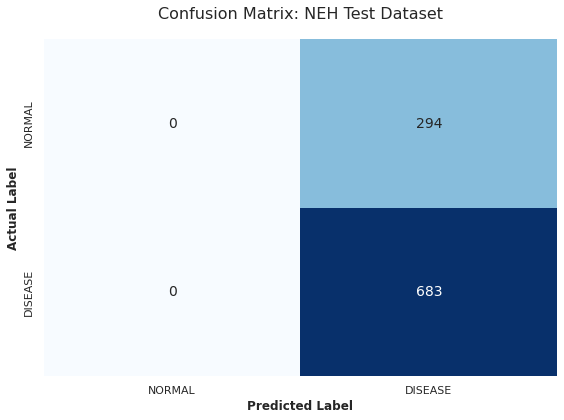


Confusion Matrix saved as 'confusion_matrix_neh.png'


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create the confusion matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = ["NORMAL", "DISEASE"]

# Set up the figure
plt.figure(figsize=(8, 6))
sns.set_theme(style="white") # Cleaner background

# Plot using seaborn heatmap
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names,
    cbar=False,
    annot_kws={"size": 14}
)

# Formatting
plt.title("Confusion Matrix: NEH Test Dataset", fontsize=16, pad=20)
plt.ylabel('Actual Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.tight_layout()

# Save and Show
plt.savefig("confusion_matrix_neh.png", dpi=300)
plt.show()

print("\nConfusion Matrix saved as 'confusion_matrix_neh.png'")

Loading NEH-trained model from: /mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/resnet18_neh_binary/epoch_16.pth
Starting inference on UCSD dataset (1000 images)...


Testing: 100%|██████████| 32/32 [00:02<00:00, 11.55it/s]



UCSD TEST PERFORMANCE (NEH MODEL)
Accuracy:  0.9110
F1 Score:  0.9419
Precision: 0.9232
Recall:    0.9613
AUC:       0.9446
------------------------------
Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.87      0.76      0.81       250
     DISEASE       0.92      0.96      0.94       750

    accuracy                           0.91      1000
   macro avg       0.90      0.86      0.88      1000
weighted avg       0.91      0.91      0.91      1000



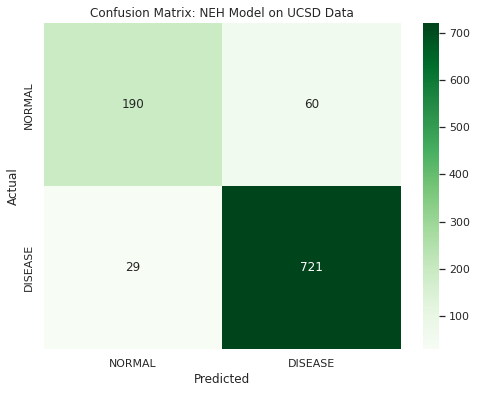


Analysis Complete. Confusion matrix saved as 'confusion_matrix_neh_on_ucsd.png'.


In [8]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import (f1_score, roc_auc_score, accuracy_score, 
                             precision_score, recall_score, classification_report, 
                             confusion_matrix)

# ===============================
# 1. Configuration & Paths (Reversed)
# ===============================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# NEH Trained Model
CKPT_PATH = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/resnet18_neh_binary/epoch_16.pth"
# UCSD Test Data
TEST_UCSD_CSV = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/test_ucsd.csv"

IMG_SIZE = 512
NUM_CLASSES = 2
BATCH_SIZE = 32

# ===============================
# 2. Model Definition
# ===============================
class ResNet18_OCT(nn.Module):
    def __init__(self, num_classes=2, pretrained=False):
        super().__init__()
        self.backbone = models.resnet18(weights=None) # pretrained=False is deprecated in newer torchvision
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

# ===============================
# 3. Dataset Class
# ===============================
class UCSDOCTDataset(Dataset):
    def __init__(self, df, transform=None, label_col="binary_label"):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["new_file_path"]
        label = int(row[self.label_col])
        
        img = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, label

# ===============================
# 4. Initialization & Loading
# ===============================
print(f"Loading NEH-trained model from: {CKPT_PATH}")
model = ResNet18_OCT(num_classes=NUM_CLASSES).to(DEVICE)

# Load checkpoint
checkpoint = torch.load(CKPT_PATH, map_location=DEVICE)
# Handling cases where state_dict might be nested or direct
state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
model.load_state_dict(state_dict)
model.eval()

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

df_ucsd = pd.read_csv(TEST_UCSD_CSV)
test_dataset = UCSDOCTDataset(df_ucsd, transform=test_transform, label_col="binary_label")
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# ===============================
# 5. Inference Loop
# ===============================
all_preds = []
all_probs = []
all_labels = []

print(f"Starting inference on UCSD dataset ({len(df_ucsd)} images)...")
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(DEVICE)
        outputs = model(images)
        
        probs = torch.softmax(outputs, dim=1)[:, 1]
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

# ===============================
# 6. Performance Metrics
# ===============================
acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)

print("\n" + "="*30)
print("UCSD TEST PERFORMANCE (NEH MODEL)")
print("="*30)
print(f"Accuracy:  {acc:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"AUC:       {auc:.4f}")
print("-" * 30)
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=["NORMAL", "DISEASE"]))

# ===============================
# 7. Confusion Matrix Plotting
# ===============================
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=["NORMAL", "DISEASE"], 
            yticklabels=["NORMAL", "DISEASE"])
plt.title("Confusion Matrix: NEH Model on UCSD Data")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig("confusion_matrix_neh_on_ucsd.png")
plt.show()

print("\nAnalysis Complete. Confusion matrix saved as 'confusion_matrix_neh_on_ucsd.png'.")

Loading NEH-trained model from: /mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/resnet18_neh_binary/epoch_11.pth
Starting inference on UCSD dataset (14882 images)...


Testing: 100%|██████████| 466/466 [01:11<00:00,  6.55it/s]



UCSD TEST PERFORMANCE (NEH MODEL)
Accuracy:  0.7020
F1 Score:  0.7583
Precision: 0.6484
Recall:    0.9131
AUC:       0.8418
------------------------------
Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.84      0.48      0.61      7263
     DISEASE       0.65      0.91      0.76      7619

    accuracy                           0.70     14882
   macro avg       0.74      0.70      0.68     14882
weighted avg       0.74      0.70      0.69     14882



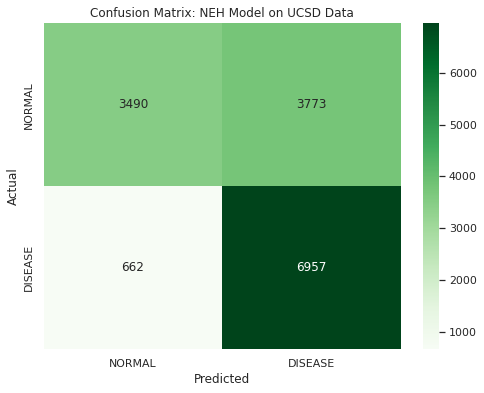


Analysis Complete. Confusion matrix saved as 'confusion_matrix_neh_on_ucsd.png'.


In [10]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import (f1_score, roc_auc_score, accuracy_score, 
                             precision_score, recall_score, classification_report, 
                             confusion_matrix)

# ===============================
# 1. Configuration & Paths (Reversed)
# ===============================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# NEH Trained Model
CKPT_PATH = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/resnet18_neh_binary/epoch_11.pth"
# UCSD Test Data
TEST_UCSD_CSV = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/ucsd_split_test_15.csv"

IMG_SIZE = 512
NUM_CLASSES = 2
BATCH_SIZE = 32

# ===============================
# 2. Model Definition
# ===============================
class ResNet18_OCT(nn.Module):
    def __init__(self, num_classes=2, pretrained=False):
        super().__init__()
        self.backbone = models.resnet18(weights=None) # pretrained=False is deprecated in newer torchvision
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

# ===============================
# 3. Dataset Class
# ===============================
class UCSDOCTDataset(Dataset):
    def __init__(self, df, transform=None, label_col="binary_label"):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["new_file_path"]
        label = int(row[self.label_col])
        
        img = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, label

# ===============================
# 4. Initialization & Loading
# ===============================
print(f"Loading NEH-trained model from: {CKPT_PATH}")
model = ResNet18_OCT(num_classes=NUM_CLASSES).to(DEVICE)

# Load checkpoint
checkpoint = torch.load(CKPT_PATH, map_location=DEVICE)
# Handling cases where state_dict might be nested or direct
state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
model.load_state_dict(state_dict)
model.eval()

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

df_ucsd = pd.read_csv(TEST_UCSD_CSV)
test_dataset = UCSDOCTDataset(df_ucsd, transform=test_transform, label_col="binary_label")
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# ===============================
# 5. Inference Loop
# ===============================
all_preds = []
all_probs = []
all_labels = []

print(f"Starting inference on UCSD dataset ({len(df_ucsd)} images)...")
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(DEVICE)
        outputs = model(images)
        
        probs = torch.softmax(outputs, dim=1)[:, 1]
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

# ===============================
# 6. Performance Metrics
# ===============================
acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)

print("\n" + "="*30)
print("UCSD TEST PERFORMANCE (NEH MODEL)")
print("="*30)
print(f"Accuracy:  {acc:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"AUC:       {auc:.4f}")
print("-" * 30)
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=["NORMAL", "DISEASE"]))

# ===============================
# 7. Confusion Matrix Plotting
# ===============================
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=["NORMAL", "DISEASE"], 
            yticklabels=["NORMAL", "DISEASE"])
plt.title("Confusion Matrix: NEH Model on UCSD Data")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig("confusion_matrix_neh_on_ucsd.png")
plt.show()

print("\nAnalysis Complete. Confusion matrix saved as 'confusion_matrix_neh_on_ucsd.png'.")


Evaluating Epoch 12...


Epoch 12 | Macro F1: 0.7528 | Acc: 0.8550 | NPV: 0.9907

Evaluating Epoch 13...


Epoch 13 | Macro F1: 0.7912 | Acc: 0.8720 | NPV: 0.9766

Evaluating Epoch 14...


Epoch 14 | Macro F1: 0.8269 | Acc: 0.8880 | NPV: 0.9423

Evaluating Epoch 15...


Epoch 15 | Macro F1: 0.8300 | Acc: 0.8900 | NPV: 0.9487

Evaluating Epoch 16...


...

Epoch 18 | Macro F1: 0.8331 | Acc: 0.8910 | NPV: 0.9379

Evaluating Epoch 19...


Epoch 19 | Macro F1: 0.8528 | Acc: 0.9020 | NPV: 0.9419

Evaluating Epoch 20...


Epoch 20 | Macro F1: 0.8189 | Acc: 0.8830 | NPV: 0.9290

Evaluating Epoch 21...


Epoch 21 | Macro F1: 0.8414 | Acc: 0.8940 | NPV: 0.9138

Evaluating Epoch 22...


Epoch 22 | Macro F1: 0.8480 | Acc: 0.8960 | NPV: 0.8883


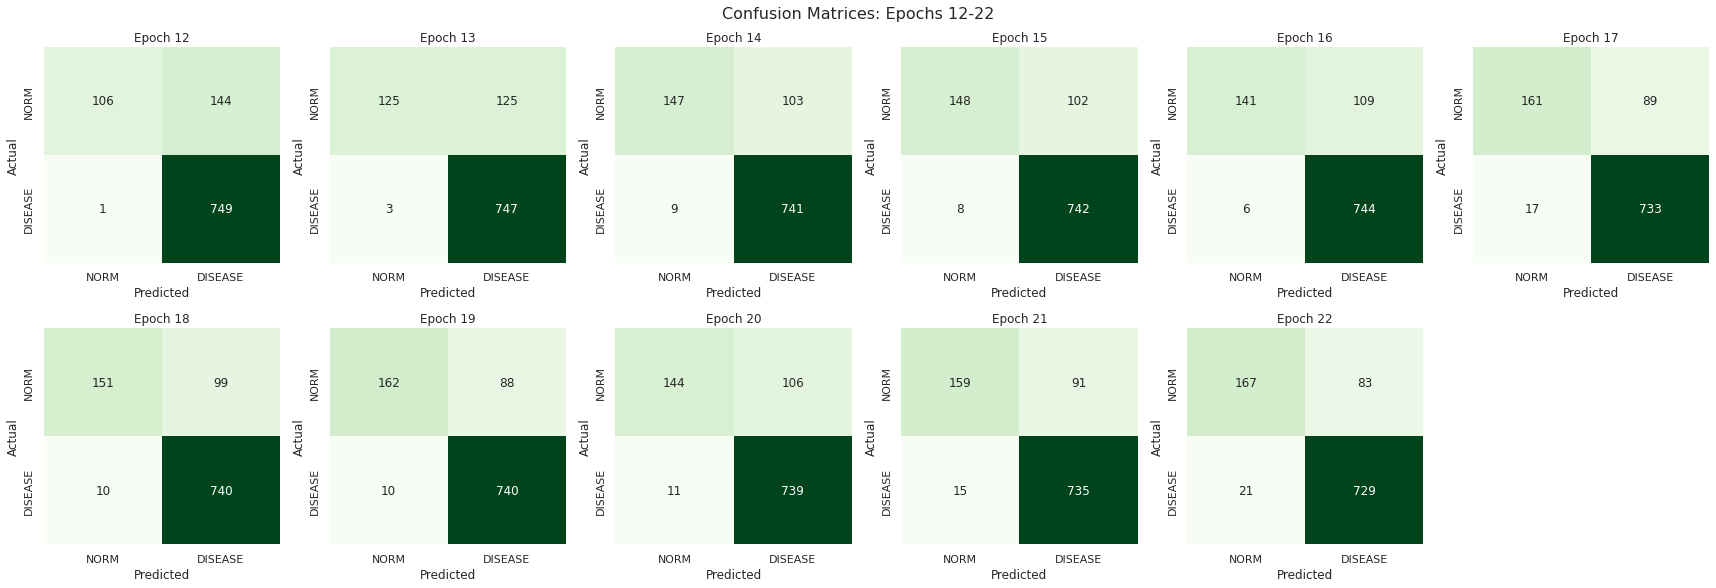


All inferences complete. Plot saved as 'multi_epoch_confusion_matrices.png'.


In [17]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import (f1_score, roc_auc_score, accuracy_score, 
                             precision_score, recall_score, classification_report, 
                             confusion_matrix)

# ===============================
# 1. Configuration & Paths
# ===============================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_CKPT_DIR = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/resnet18_neh_binary/"
TEST_UCSD_CSV = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/ucsd_test.csv"

IMG_SIZE = 512
NUM_CLASSES = 2
BATCH_SIZE = 32
EPOCHS_TO_TEST = range(12, 23)  # 12 to 22 inclusive

# ===============================
# 2. Model & Dataset Classes
# ===============================
class ResNet18_OCT(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

class UCSDOCTDataset(Dataset):
    def __init__(self, df, transform=None, label_col="binary_label"):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["new_file_path"]
        label = int(row[self.label_col])
        img = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, label

# ===============================
# 3. Setup Data
# ===============================
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

df_ucsd = pd.read_csv(TEST_UCSD_CSV)
test_dataset = UCSDOCTDataset(df_ucsd, transform=test_transform, label_col="binary_label")
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# To store results for plotting
all_cms = []
epoch_list = []

model = ResNet18_OCT(num_classes=NUM_CLASSES).to(DEVICE)

# ===============================
# 4. Inference Loop
# ===============================
for epoch in EPOCHS_TO_TEST:
    ckpt_path = os.path.join(BASE_CKPT_DIR, f"epoch_{epoch}.pth")
    if not os.path.exists(ckpt_path):
        print(f"Skipping: {ckpt_path} not found.")
        continue

    print(f"\nEvaluating Epoch {epoch}...")
    checkpoint = torch.load(ckpt_path, map_location=DEVICE)
    state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
    model.load_state_dict(state_dict)
    model.eval()

    epoch_preds = []
    epoch_labels = []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Epoch {epoch}", leave=False):
            images = images.to(DEVICE)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            epoch_preds.extend(preds.cpu().numpy())
            epoch_labels.extend(labels.numpy())

    # Metrics
    macro_f1 = f1_score(epoch_labels, epoch_preds, average='macro')
    acc = accuracy_score(epoch_labels, epoch_preds)
    
    # Confusion Matrix Components
    cm = confusion_matrix(epoch_labels, epoch_preds)
    tn, fp, fn, tp = cm.ravel()
    npv = tn / (tn + fn + 1e-8)

    print(f"Epoch {epoch} | Macro F1: {macro_f1:.4f} | Acc: {acc:.4f} | NPV: {npv:.4f}")
    
    all_cms.append(cm)
    epoch_list.append(epoch)

# ===============================
# 5. Final Subplot Visualization
# ===============================
fig, axes = plt.subplots(2, 6, figsize=(24, 8)) # 2x6 to accommodate up to 11/12 epochs comfortably
axes = axes.flatten()

for i, (cm, ep) in enumerate(zip(all_cms, epoch_list)):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[i], cbar=False,
                xticklabels=["NORM", "DISEASE"], 
                yticklabels=["NORM", "DISEASE"])
    axes[i].set_title(f"Epoch {ep}")
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

# Remove unused subplots
for j in range(len(all_cms), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Confusion Matrices: Epochs 12-22", fontsize=16, y=1.02)
plt.savefig("multi_epoch_confusion_matrices_1ktest.png")
plt.show()

print("\nAll inferences complete. Plot saved as 'multi_epoch_confusion_matrices.png'.")


Evaluating Epoch 12...


Epoch 12 | Macro F1: 0.5050 | Acc: 0.5906 | NPV: 0.9097

Evaluating Epoch 13...


Epoch 13 | Macro F1: 0.5268 | Acc: 0.6030 | NPV: 0.9119

Evaluating Epoch 14...


Epoch 14 | Macro F1: 0.6006 | Acc: 0.6472 | NPV: 0.8967

Evaluating Epoch 15...


Epoch 15 | Macro F1: 0.5677 | Acc: 0.6263 | NPV: 0.8977

Evaluating Epoch 16...


...

Epoch 18 | Macro F1: 0.6071 | Acc: 0.6513 | NPV: 0.8940

Evaluating Epoch 19...


Epoch 19 | Macro F1: 0.6118 | Acc: 0.6550 | NPV: 0.9015

Evaluating Epoch 20...


Epoch 20 | Macro F1: 0.6444 | Acc: 0.6756 | NPV: 0.8789

Evaluating Epoch 21...


Epoch 21 | Macro F1: 0.6446 | Acc: 0.6765 | NPV: 0.8876

Evaluating Epoch 22...


Epoch 22 | Macro F1: 0.6470 | Acc: 0.6743 | NPV: 0.8471


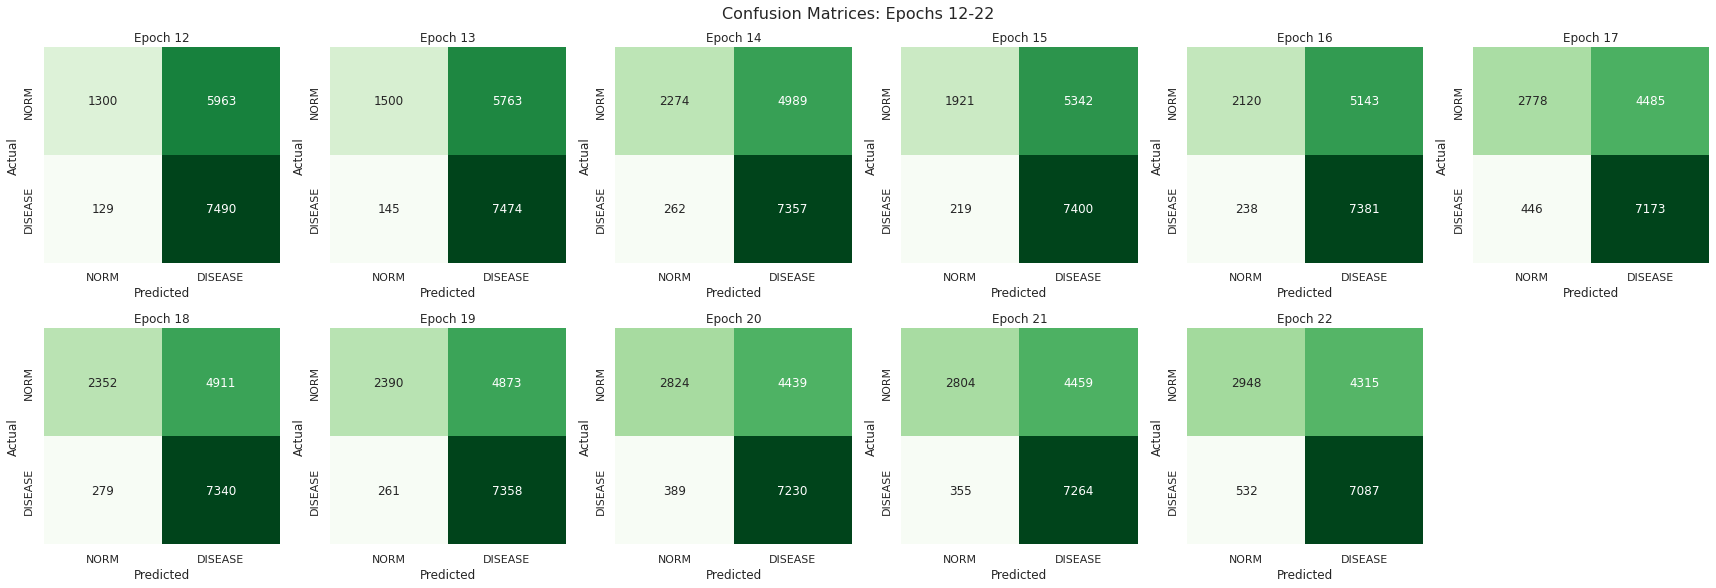


All inferences complete. Plot saved as 'multi_epoch_confusion_matrices.png'.


In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import (f1_score, roc_auc_score, accuracy_score, 
                             precision_score, recall_score, classification_report, 
                             confusion_matrix)

# ===============================
# 1. Configuration & Paths
# ===============================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_CKPT_DIR = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/resnet18_neh_binary/"
TEST_UCSD_CSV = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/ucsd_split_test_15.csv"

IMG_SIZE = 512
NUM_CLASSES = 2
BATCH_SIZE = 32
EPOCHS_TO_TEST = range(12, 23)  # 12 to 22 inclusive

# ===============================
# 2. Model & Dataset Classes
# ===============================
class ResNet18_OCT(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

class UCSDOCTDataset(Dataset):
    def __init__(self, df, transform=None, label_col="binary_label"):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["new_file_path"]
        label = int(row[self.label_col])
        img = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, label

# ===============================
# 3. Setup Data
# ===============================
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

df_ucsd = pd.read_csv(TEST_UCSD_CSV)
test_dataset = UCSDOCTDataset(df_ucsd, transform=test_transform, label_col="binary_label")
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# To store results for plotting
all_cms = []
epoch_list = []

model = ResNet18_OCT(num_classes=NUM_CLASSES).to(DEVICE)

# ===============================
# 4. Inference Loop
# ===============================
for epoch in EPOCHS_TO_TEST:
    ckpt_path = os.path.join(BASE_CKPT_DIR, f"epoch_{epoch}.pth")
    if not os.path.exists(ckpt_path):
        print(f"Skipping: {ckpt_path} not found.")
        continue

    print(f"\nEvaluating Epoch {epoch}...")
    checkpoint = torch.load(ckpt_path, map_location=DEVICE)
    state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
    model.load_state_dict(state_dict)
    model.eval()

    epoch_preds = []
    epoch_labels = []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Epoch {epoch}", leave=False):
            images = images.to(DEVICE)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            epoch_preds.extend(preds.cpu().numpy())
            epoch_labels.extend(labels.numpy())

    # Metrics
    macro_f1 = f1_score(epoch_labels, epoch_preds, average='macro')
    acc = accuracy_score(epoch_labels, epoch_preds)
    
    # Confusion Matrix Components
    cm = confusion_matrix(epoch_labels, epoch_preds)
    tn, fp, fn, tp = cm.ravel()
    npv = tn / (tn + fn + 1e-8)

    print(f"Epoch {epoch} | Macro F1: {macro_f1:.4f} | Acc: {acc:.4f} | NPV: {npv:.4f}")
    
    all_cms.append(cm)
    epoch_list.append(epoch)

# ===============================
# 5. Final Subplot Visualization
# ===============================
fig, axes = plt.subplots(2, 6, figsize=(24, 8)) # 2x6 to accommodate up to 11/12 epochs comfortably
axes = axes.flatten()

for i, (cm, ep) in enumerate(zip(all_cms, epoch_list)):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[i], cbar=False,
                xticklabels=["NORM", "DISEASE"], 
                yticklabels=["NORM", "DISEASE"])
    axes[i].set_title(f"Epoch {ep}")
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

# Remove unused subplots
for j in range(len(all_cms), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Confusion Matrices: Epochs 12-22", fontsize=16, y=1.02)
plt.savefig("multi_epoch_confusion_matrices.png")
plt.show()

print("\nAll inferences complete. Plot saved as 'multi_epoch_confusion_matrices.png'.")


Evaluating Epoch 12...


Epoch 12 | Macro F1: 0.8291 | Acc: 0.8326 | NPV: 0.9362

Evaluating Epoch 13...


Epoch 13 | Macro F1: 0.7563 | Acc: 0.7677 | NPV: 0.9331

Evaluating Epoch 14...


Epoch 14 | Macro F1: 0.7922 | Acc: 0.7979 | NPV: 0.9119

Evaluating Epoch 15...


Epoch 15 | Macro F1: 0.8070 | Acc: 0.8113 | NPV: 0.9126

Evaluating Epoch 16...


...

Epoch 18 | Macro F1: 0.6448 | Acc: 0.6810 | NPV: 0.9380

Evaluating Epoch 19...


Epoch 19 | Macro F1: 0.8174 | Acc: 0.8220 | NPV: 0.9383

Evaluating Epoch 20...


Epoch 20 | Macro F1: 0.8158 | Acc: 0.8212 | NPV: 0.9533

Evaluating Epoch 21...


Epoch 21 | Macro F1: 0.8354 | Acc: 0.8387 | NPV: 0.9394

Evaluating Epoch 22...


Epoch 22 | Macro F1: 0.8472 | Acc: 0.8496 | NPV: 0.9367


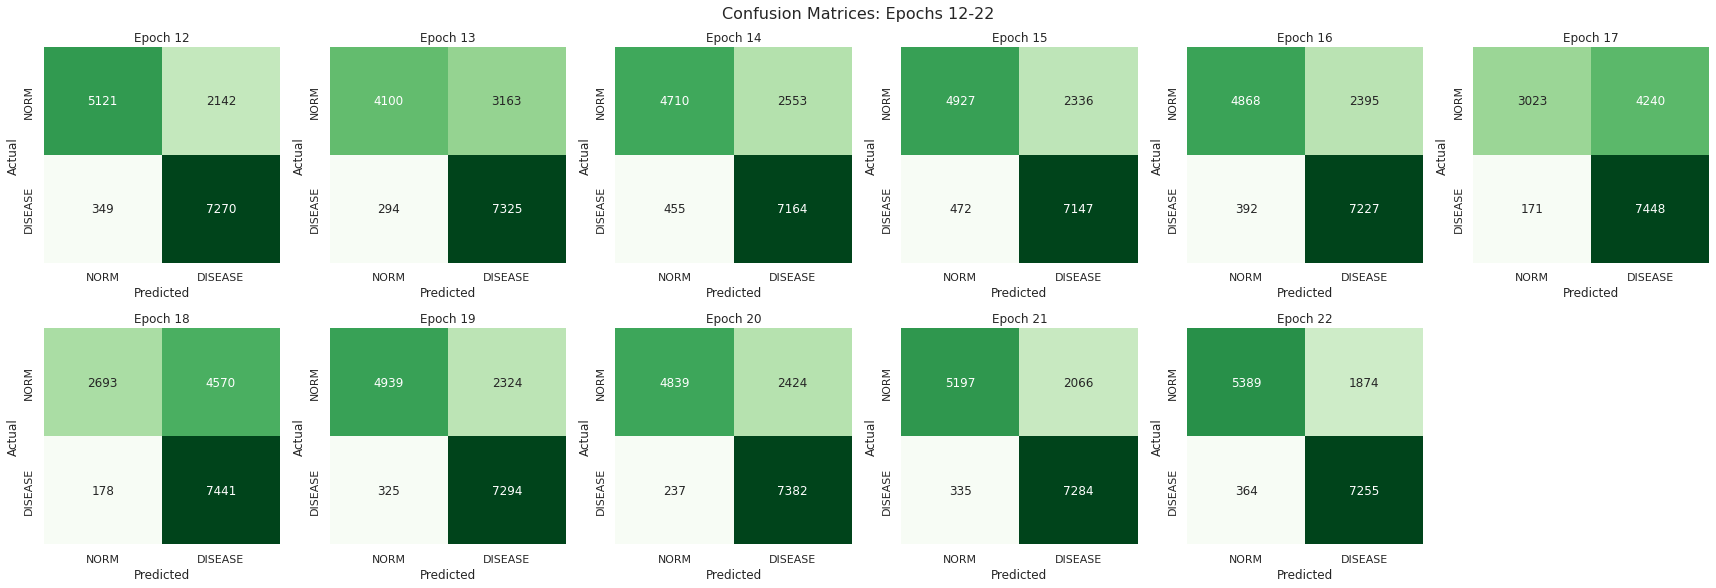


All inferences complete. Plot saved as 'multi_epoch_confusion_matrices.png'.


In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import (f1_score, roc_auc_score, accuracy_score, 
                             precision_score, recall_score, classification_report, 
                             confusion_matrix)

# ===============================
# 1. Configuration & Paths
# ===============================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_CKPT_DIR = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/resnet34_neh_binary_1e4/"
TEST_UCSD_CSV = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/ucsd_split_test_15.csv"

IMG_SIZE = 512
NUM_CLASSES = 2
BATCH_SIZE = 32
EPOCHS_TO_TEST = range(12, 23)  # 12 to 22 inclusive

# ===============================
# 2. Model & Dataset Classes
# ===============================
class ResNet18_OCT(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

class UCSDOCTDataset(Dataset):
    def __init__(self, df, transform=None, label_col="binary_label"):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["new_file_path"]
        label = int(row[self.label_col])
        img = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, label

# ===============================
# 3. Setup Data
# ===============================
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

df_ucsd = pd.read_csv(TEST_UCSD_CSV)
test_dataset = UCSDOCTDataset(df_ucsd, transform=test_transform, label_col="binary_label")
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# To store results for plotting
all_cms = []
epoch_list = []

model = ResNet18_OCT(num_classes=NUM_CLASSES).to(DEVICE)

# ===============================
# 4. Inference Loop
# ===============================
for epoch in EPOCHS_TO_TEST:
    ckpt_path = os.path.join(BASE_CKPT_DIR, f"epoch_{epoch}.pth")
    if not os.path.exists(ckpt_path):
        print(f"Skipping: {ckpt_path} not found.")
        continue

    print(f"\nEvaluating Epoch {epoch}...")
    checkpoint = torch.load(ckpt_path, map_location=DEVICE)
    state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
    model.load_state_dict(state_dict)
    model.eval()

    epoch_preds = []
    epoch_labels = []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Epoch {epoch}", leave=False):
            images = images.to(DEVICE)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            epoch_preds.extend(preds.cpu().numpy())
            epoch_labels.extend(labels.numpy())

    # Metrics
    macro_f1 = f1_score(epoch_labels, epoch_preds, average='macro')
    acc = accuracy_score(epoch_labels, epoch_preds)
    
    # Confusion Matrix Components
    cm = confusion_matrix(epoch_labels, epoch_preds)
    tn, fp, fn, tp = cm.ravel()
    npv = tn / (tn + fn + 1e-8)

    print(f"Epoch {epoch} | Macro F1: {macro_f1:.4f} | Acc: {acc:.4f} | NPV: {npv:.4f}")
    
    all_cms.append(cm)
    epoch_list.append(epoch)

# ===============================
# 5. Final Subplot Visualization
# ===============================
fig, axes = plt.subplots(2, 6, figsize=(24, 8)) # 2x6 to accommodate up to 11/12 epochs comfortably
axes = axes.flatten()

for i, (cm, ep) in enumerate(zip(all_cms, epoch_list)):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[i], cbar=False,
                xticklabels=["NORM", "DISEASE"], 
                yticklabels=["NORM", "DISEASE"])
    axes[i].set_title(f"Epoch {ep}")
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

# Remove unused subplots
for j in range(len(all_cms), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Confusion Matrices: Epochs 12-22", fontsize=16, y=1.02)
plt.savefig("multi_epoch_confusion_matrices_1e4.png")
plt.show()

print("\nAll inferences complete. Plot saved as 'multi_epoch_confusion_matrices.png'.")

/home/bharath/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/home/bharath/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/bharath/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  


Evaluating Epoch 7...


Epoch 7 | Macro F1: 0.6941 | Acc: 0.7155 | NPV: 0.9108

Evaluating Epoch 8...


Epoch 8 | Macro F1: 0.7767 | Acc: 0.7841 | NPV: 0.9124

Evaluating Epoch 9...


Epoch 9 | Macro F1: 0.8221 | Acc: 0.8247 | NPV: 0.8986

Evaluating Epoch 10...


...

Epoch 13 | Macro F1: 0.8465 | Acc: 0.8471 | NPV: 0.8737

Evaluating Epoch 14...


Epoch 14 | Macro F1: 0.8469 | Acc: 0.8469 | NPV: 0.8304

Evaluating Epoch 15...


Epoch 15 | Macro F1: 0.8410 | Acc: 0.8415 | NPV: 0.8606

Evaluating Epoch 16...


Epoch 16 | Macro F1: 0.8219 | Acc: 0.8245 | NPV: 0.8987

Evaluating Epoch 17...


Epoch 17 | Macro F1: 0.8420 | Acc: 0.8435 | NPV: 0.8992


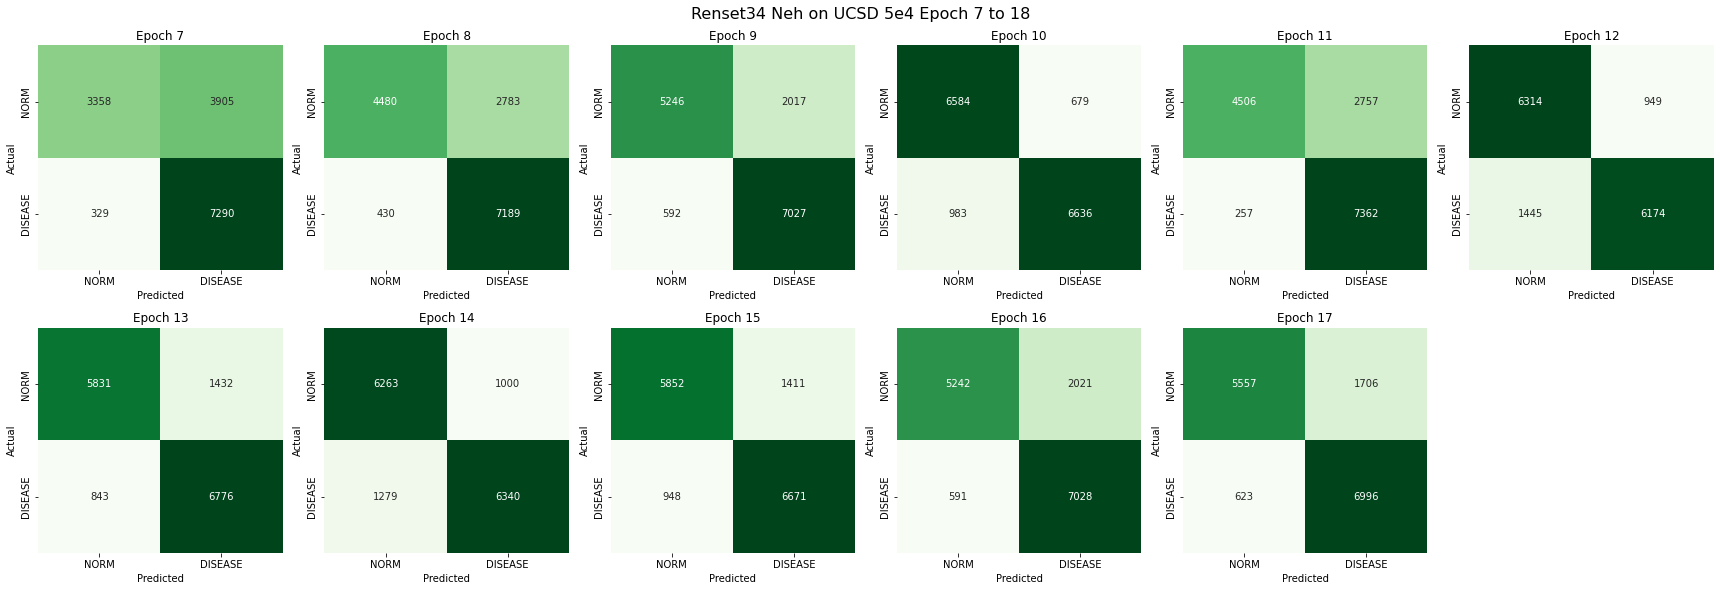


All inferences complete. Plot saved as 'multi_epoch_confusion_matrices.png'.


In [2]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import (f1_score, roc_auc_score, accuracy_score, 
                             precision_score, recall_score, classification_report, 
                             confusion_matrix)

# ===============================
# 1. Configuration & Paths
# ===============================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_CKPT_DIR = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/resnet34_neh_binary_5e4/"
TEST_UCSD_CSV = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/ucsd_split_test_15.csv"

IMG_SIZE = 512
NUM_CLASSES = 2
BATCH_SIZE = 32
EPOCHS_TO_TEST = range(7, 18)  # 12 to 22 inclusive

# ===============================
# 2. Model & Dataset Classes
# ===============================
class ResNet34_OCT(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()

        # Load ResNet34 backbone
        # Note: In newer torchvision versions, weights=models.ResNet34_Weights.DEFAULT 
        # is preferred over pretrained=True
        self.backbone = models.resnet34(pretrained=pretrained)

        # Replace final fully connected layer
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

# Initialize and move to device
model = ResNet34_OCT(
    num_classes=NUM_CLASSES,
    pretrained=True
).to(DEVICE)

class UCSDOCTDataset(Dataset):
    def __init__(self, df, transform=None, label_col="binary_label"):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["new_file_path"]
        label = int(row[self.label_col])
        img = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, label

# ===============================
# 3. Setup Data
# ===============================
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

df_ucsd = pd.read_csv(TEST_UCSD_CSV)
test_dataset = UCSDOCTDataset(df_ucsd, transform=test_transform, label_col="binary_label")
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# To store results for plotting
all_cms = []
epoch_list = []


# ===============================
# 4. Inference Loop
# ===============================
for epoch in EPOCHS_TO_TEST:
    ckpt_path = os.path.join(BASE_CKPT_DIR, f"epoch_{epoch}.pth")
    if not os.path.exists(ckpt_path):
        print(f"Skipping: {ckpt_path} not found.")
        continue

    print(f"\nEvaluating Epoch {epoch}...")
    checkpoint = torch.load(ckpt_path, map_location=DEVICE)
    state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
    model.load_state_dict(state_dict)
    model.eval()

    epoch_preds = []
    epoch_labels = []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Epoch {epoch}", leave=False):
            images = images.to(DEVICE)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            epoch_preds.extend(preds.cpu().numpy())
            epoch_labels.extend(labels.numpy())

    # Metrics
    macro_f1 = f1_score(epoch_labels, epoch_preds, average='macro')
    acc = accuracy_score(epoch_labels, epoch_preds)
    
    # Confusion Matrix Components
    cm = confusion_matrix(epoch_labels, epoch_preds)
    tn, fp, fn, tp = cm.ravel()
    npv = tn / (tn + fn + 1e-8)

    print(f"Epoch {epoch} | Macro F1: {macro_f1:.4f} | Acc: {acc:.4f} | NPV: {npv:.4f}")
    
    all_cms.append(cm)
    epoch_list.append(epoch)

# ===============================
# 5. Final Subplot Visualization
# ===============================
fig, axes = plt.subplots(2, 6, figsize=(24, 8)) # 2x6 to accommodate up to 11/12 epochs comfortably
axes = axes.flatten()

for i, (cm, ep) in enumerate(zip(all_cms, epoch_list)):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[i], cbar=False,
                xticklabels=["NORM", "DISEASE"], 
                yticklabels=["NORM", "DISEASE"])
    axes[i].set_title(f"Epoch {ep}")
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

# Remove unused subplots
for j in range(len(all_cms), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Renset34 Neh on UCSD 5e4 Epoch 7 to 18", fontsize=16, y=1.02)
plt.savefig("confusionM_resnet34_NehOnUCSD_5e4.png")
plt.show()

print("\nAll inferences complete. Plot saved as 'multi_epoch_confusion_matrices.png'.")

Starting inference on NEH dataset using UCSD checkpoints [18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]...


Epoch 18 | Acc: 0.6950 | Macro F1: 0.4100 | AUC: 0.4963 | NPV: 0.0000


Epoch 19 | Acc: 0.6960 | Macro F1: 0.4104 | AUC: 0.4971 | NPV: 0.0000


Epoch 20 | Acc: 0.6970 | Macro F1: 0.4107 | AUC: 0.4971 | NPV: 0.0000


Epoch 21 | Acc: 0.6991 | Macro F1: 0.4114 | AUC: 0.4993 | NPV: 0.0000


...

Epoch 24 | Acc: 0.6981 | Macro F1: 0.4111 | AUC: 0.4971 | NPV: 0.0000


Epoch 25 | Acc: 0.6981 | Macro F1: 0.4111 | AUC: 0.4971 | NPV: 0.0000


Epoch 26 | Acc: 0.6960 | Macro F1: 0.4104 | AUC: 0.4963 | NPV: 0.0000


Epoch 27 | Acc: 0.6981 | Macro F1: 0.4111 | AUC: 0.4978 | NPV: 0.0000


Epoch 28 | Acc: 0.6981 | Macro F1: 0.4111 | AUC: 0.4978 | NPV: 0.0000


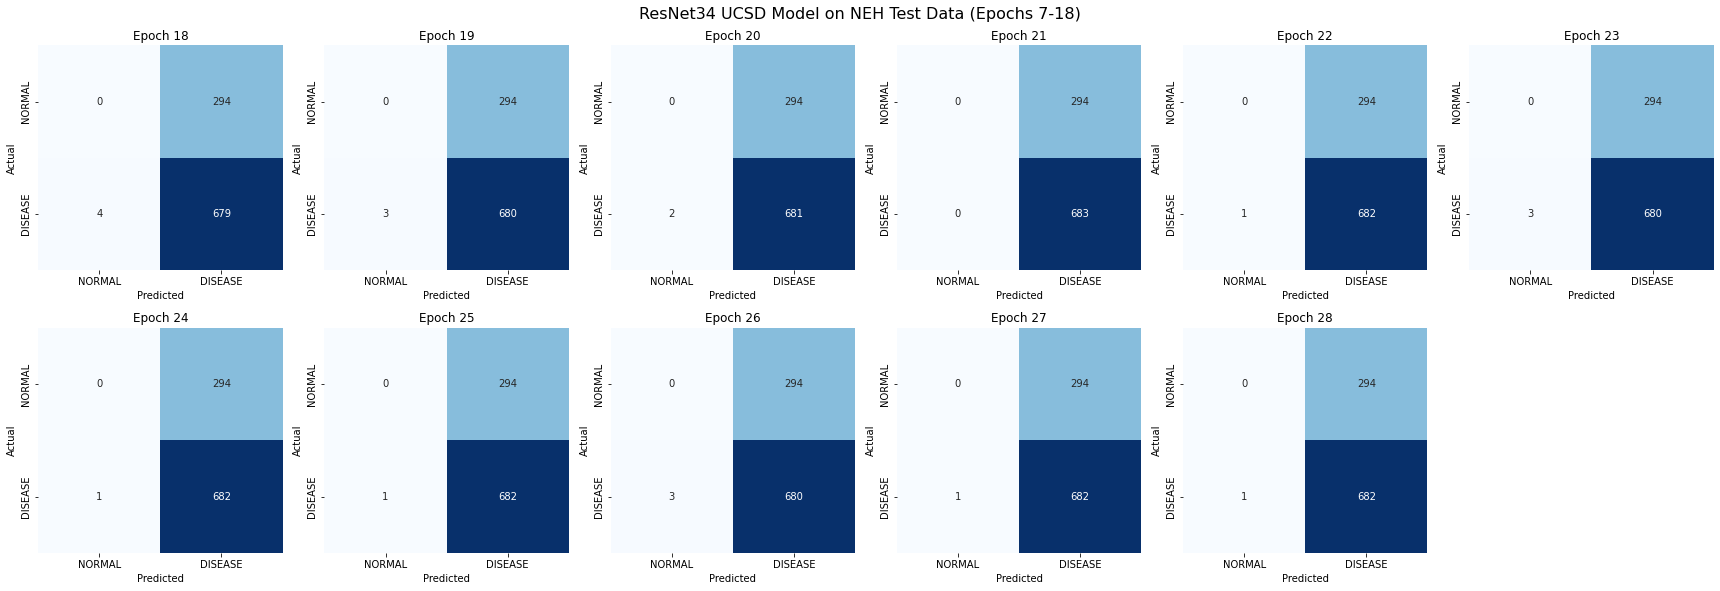


Analysis complete. Plot saved as 'confusionM_resnet34_UCSDonNEH.png'.


In [5]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from PIL import Image, ImageFile
from tqdm import tqdm
from sklearn.metrics import (f1_score, roc_auc_score, accuracy_score, 
                             precision_score, recall_score, classification_report, 
                             confusion_matrix)

# Handle truncated images
ImageFile.LOAD_TRUNCATED_IMAGES = True

# ===============================
# 1. Configuration & Paths
# ===============================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Directory containing UCSD-trained ResNet34 checkpoints
BASE_CKPT_DIR = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/resnet34_UCSD_binary_5e4_EDL"
# NEH Test CSV
TEST_NEH_CSV = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/neh_test.csv"

IMG_SIZE = 512
NUM_CLASSES = 2
BATCH_SIZE = 32
EPOCHS_TO_TEST = range(18, 29)  # Epochs 7 to 18 inclusive

# ===============================
# 2. Model & Dataset Classes
# ===============================
class ResNet34_OCT(nn.Module):
    def __init__(self, num_classes=2, pretrained=False):
        super().__init__()
        # Use weights=None since we are loading our own checkpoints
        self.backbone = models.resnet34(weights=None)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

class NEHOCTDataset(Dataset):
    def __init__(self, df, transform=None, label_col="binary_label"):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row["new_file_path"]).convert("RGB")
        except Exception as e:
            raise RuntimeError(f"Failed to load image: {row['new_file_path']}") from e
        
        label = int(row[self.label_col])
        if self.transform:
            img = self.transform(img)
        return img, label

# ===============================
# 3. Setup Data & Model
# ===============================
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

df_neh = pd.read_csv(TEST_NEH_CSV)
test_dataset = NEHOCTDataset(df_neh, transform=test_transform, label_col="binary_label")
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

model = ResNet34_OCT(num_classes=NUM_CLASSES).to(DEVICE)

# To store results for plotting
all_cms = []
epoch_list = []

# ===============================
# 4. Inference Loop
# ===============================
print(f"Starting inference on NEH dataset using UCSD checkpoints {list(EPOCHS_TO_TEST)}...")

for epoch in EPOCHS_TO_TEST:
    ckpt_path = os.path.join(BASE_CKPT_DIR, f"epoch_{epoch}.pth")
    if not os.path.exists(ckpt_path):
        print(f"Skipping: {ckpt_path} not found.")
        continue

    # Load Checkpoint
    checkpoint = torch.load(ckpt_path, map_location=DEVICE)
    state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
    model.load_state_dict(state_dict)
    model.eval()

    epoch_preds = []
    epoch_probs = []
    epoch_labels = []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Epoch {epoch}", leave=False):
            images = images.to(DEVICE)
            outputs = model(images)
            
            probs = torch.softmax(outputs, dim=1)[:, 1]
            _, preds = torch.max(outputs, 1)
            
            epoch_preds.extend(preds.cpu().numpy())
            epoch_probs.extend(probs.cpu().numpy())
            epoch_labels.extend(labels.numpy())

    # Calculate Metrics
    acc = accuracy_score(epoch_labels, epoch_preds)
    macro_f1 = f1_score(epoch_labels, epoch_preds, average='macro')
    auc = roc_auc_score(epoch_labels, epoch_probs)
    
    # Confusion Matrix & NPV
    cm = confusion_matrix(epoch_labels, epoch_preds)
    tn, fp, fn, tp = cm.ravel()
    npv = tn / (tn + fn + 1e-8)

    print(f"Epoch {epoch:02d} | Acc: {acc:.4f} | Macro F1: {macro_f1:.4f} | AUC: {auc:.4f} | NPV: {npv:.4f}")
    
    all_cms.append(cm)
    epoch_list.append(epoch)

# ===============================
# 5. Final Subplot Visualization
# ===============================

num_plots = len(all_cms)
cols = 6
rows = (num_plots + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(24, 4 * rows))
axes = axes.flatten()

for i, (cm, ep) in enumerate(zip(all_cms, epoch_list)):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=["NORMAL", "DISEASE"], 
                yticklabels=["NORMAL", "DISEASE"])
    axes[i].set_title(f"Epoch {ep}")
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

# Remove empty subplots
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("ResNet34 UCSD Model on NEH Test Data (Epochs 7-18)", fontsize=16, y=1.02)
plt.savefig("confusionM_resnet34_EDL_UCSDonNEH.png")
plt.show()

print("\nAnalysis complete. Plot saved as 'confusionM_resnet34_UCSDonNEH.png'.")

In [6]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import os
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from PIL import Image, ImageFile
from tqdm import tqdm
from sklearn.metrics import (f1_score, roc_auc_score, accuracy_score, 
                             precision_score, recall_score, confusion_matrix)

# Handle truncated images
ImageFile.LOAD_TRUNCATED_IMAGES = True

# ===============================
# 1. Configuration & Paths
# ===============================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT_PATH = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/resnet34_UCSD_binary_5e4_EDL/epoch_25.pth"
TEST_NEH_CSV = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/neh_test.csv"

IMG_SIZE = 512
NUM_CLASSES = 2
BATCH_SIZE = 32

# ===============================
# 2. Model & Dataset Classes
# ===============================
class ResNet34_OCT(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.backbone = models.resnet34(weights=None)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

class NEHOCTDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["new_file_path"]).convert("RGB")
        label = int(row["binary_label"])
        if self.transform:
            img = self.transform(img)
        return img, label

# ===============================
# 3. Setup & Loading
# ===============================
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

df_neh = pd.read_csv(TEST_NEH_CSV)
test_loader = DataLoader(NEHOCTDataset(df_neh, transform=test_transform), 
                         batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

model = ResNet34_OCT(num_classes=NUM_CLASSES).to(DEVICE)

print(f"Loading checkpoint: {CKPT_PATH}")
checkpoint = torch.load(CKPT_PATH, map_location=DEVICE)
state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
model.load_state_dict(state_dict)
model.eval()

# ===============================
# 4. Inference
# ===============================
all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Inference"):
        images = images.to(DEVICE)
        outputs = model(images)
        
        probs = torch.softmax(outputs, dim=1)[:, 1]
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

# ===============================
# 5. Metrics Calculation
# ===============================
# Confusion matrix for Specificity and NPV
cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()

# Macro Metrics
macro_f1  = f1_score(all_labels, all_preds, average='macro')
precision = precision_score(all_labels, all_preds, average='macro')
recall    = recall_score(all_labels, all_preds, average='macro')
acc       = accuracy_score(all_labels, all_preds)
auc       = roc_auc_score(all_labels, all_probs)

# Class-Specific Metrics (Normal vs Disease)
# Specificity = TN / (TN + FP)
specificity = tn / (tn + fp + 1e-8)
# NPV = TN / (TN + FN)
npv = tn / (tn + fn + 1e-8)

print("\n" + "="*40)
print(f"PERFORMANCE SUMMARY (EPOCH 12)")
print("="*40)
print(f"Macro F1:    {macro_f1:.4f}")
print(f"Accuracy:    {acc:.4f}")
print(f"AUC:         {auc:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"NPV:         {npv:.4f}")
print("="*40)

Loading checkpoint: /mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/resnet34_UCSD_binary_5e4_EDL/epoch_25.pth


Inference: 100%|██████████| 31/31 [00:03<00:00,  9.37it/s]


PERFORMANCE SUMMARY (EPOCH 12)
Macro F1:    0.4111
Accuracy:    0.6981
AUC:         0.4971
Precision:   0.3494
Recall:      0.4993
Specificity: 0.0000
NPV:         0.0000


/home/bharath/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/bharath/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



🔹 Evaluating Epoch 7


Epoch 07 | Acc: 0.7679 | F1: 0.7364 | AUC: 0.9440 | Prec: 0.8387 | Recall: 0.7355 | Spec: 0.4847 | NPV: 0.9646

🔹 Evaluating Epoch 8


Epoch 08 | Acc: 0.7843 | F1: 0.7596 | AUC: 0.9336 | Prec: 0.8406 | Recall: 0.7555 | Spec: 0.5323 | NPV: 0.9505

🔹 Evaluating Epoch 9


Epoch 09 | Acc: 0.8839 | F1: 0.8804 | AUC: 0.9565 | Prec: 0.8880 | Recall: 0.8763 | Spec: 0.8173 | NPV: 0.9069

🔹 Evaluating Epoch 10


...

Epoch 20 | Acc: 0.8722 | F1: 0.8670 | AUC: 0.9545 | Prec: 0.8818 | Recall: 0.8611 | Spec: 0.7754 | NPV: 0.9184

🔹 Evaluating Epoch 21


Epoch 21 | Acc: 0.8669 | F1: 0.8612 | AUC: 0.9529 | Prec: 0.8779 | Recall: 0.8550 | Spec: 0.7626 | NPV: 0.9179

🔹 Evaluating Epoch 22


Epoch 22 | Acc: 0.8830 | F1: 0.8796 | AUC: 0.9553 | Prec: 0.8862 | Recall: 0.8759 | Spec: 0.8209 | NPV: 0.9016

🔹 Evaluating Epoch 23


Epoch 23 | Acc: 0.8858 | F1: 0.8831 | AUC: 0.9544 | Prec: 0.8863 | Recall: 0.8809 | Spec: 0.8429 | NPV: 0.8891

🔹 Evaluating Epoch 24


Epoch 24 | Acc: 0.8802 | F1: 0.8761 | AUC: 0.9546 | Prec: 0.8865 | Recall: 0.8712 | Spec: 0.8010 | NPV: 0.9133


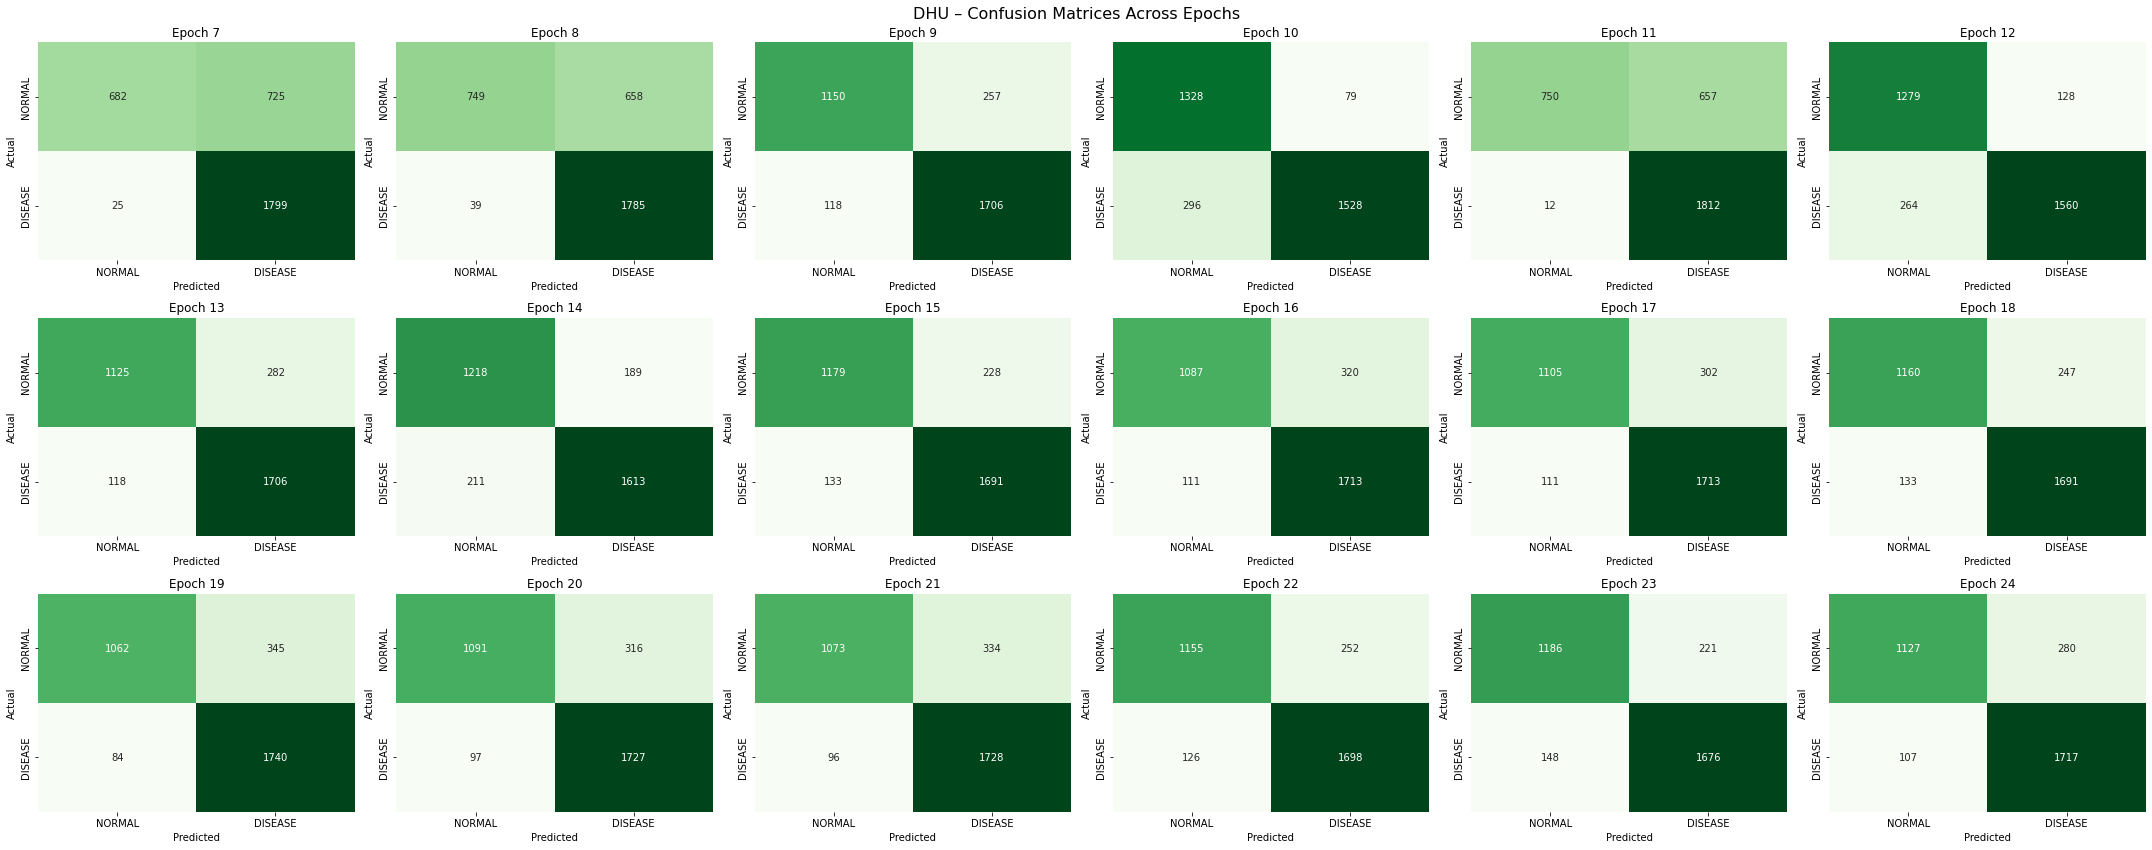


✅ All confusion matrices plotted and saved.


In [4]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score,
    precision_score, recall_score, confusion_matrix
)

# ===============================
# CONFIG
# ===============================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_CKPT_DIR = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/resnet34_neh_binary_5e4/"
DHU_CSV = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/dhu.csv"

IMG_SIZE = 512
BATCH_SIZE = 32
EPOCHS_TO_TEST = range(7, 25)

# ===============================
# MODEL
# ===============================
class ResNet34_OCT(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.backbone = models.resnet34(pretrained=True)
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

model = ResNet34_OCT().to(DEVICE)

# ===============================
# DATASET
# ===============================
class DHUDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["new_file_path"]).convert("RGB")
        label = int(row["binary_label"])

        if self.transform:
            img = self.transform(img)

        return img, label

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

df = pd.read_csv(DHU_CSV)
dataset = DHUDataset(df, transform)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# ===============================
# INFERENCE LOOP
# ===============================
all_cms = []
epoch_list = []

for epoch in EPOCHS_TO_TEST:

    ckpt_path = os.path.join(BASE_CKPT_DIR, f"epoch_{epoch}.pth")
    if not os.path.exists(ckpt_path):
        print(f"Skipping epoch {epoch} (checkpoint not found)")
        continue

    print(f"\n🔹 Evaluating Epoch {epoch}")

    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(
        ckpt["model_state_dict"] if "model_state_dict" in ckpt else ckpt
    )
    model.eval()

    all_probs, all_preds, all_targets = [], [], []

    with torch.no_grad():
        for imgs, labels in tqdm(loader, leave=False):
            imgs = imgs.to(DEVICE)

            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.numpy())

    # Metrics
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average="macro")
    prec = precision_score(all_targets, all_preds, average="macro")
    rec = recall_score(all_targets, all_preds, average="macro")
    auc = roc_auc_score(all_targets, all_probs)

    cm = confusion_matrix(all_targets, all_preds)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp + 1e-8)
    npv = tn / (tn + fn + 1e-8)

    print(
        f"Epoch {epoch:02d} | "
        f"Acc: {acc:.4f} | "
        f"F1: {f1:.4f} | "
        f"AUC: {auc:.4f} | "
        f"Prec: {prec:.4f} | "
        f"Recall: {rec:.4f} | "
        f"Spec: {specificity:.4f} | "
        f"NPV: {npv:.4f}"
    )

    all_cms.append(cm)
    epoch_list.append(epoch)

# ===============================
# CONFUSION MATRIX PLOT
# ===============================
rows = 3
cols = int(np.ceil(len(all_cms) / rows))

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 12))
axes = axes.flatten()

for i, (cm, ep) in enumerate(zip(all_cms, epoch_list)):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Greens",
        cbar=False,
        xticklabels=["NORMAL", "DISEASE"],
        yticklabels=["NORMAL", "DISEASE"],
        ax=axes[i]
    )
    axes[i].set_title(f"Epoch {ep}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

# Remove empty plots
for j in range(len(all_cms), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("DHU – Confusion Matrices Across Epochs", fontsize=16)
plt.tight_layout()
plt.savefig("DHU_confusion_matrices_all_epochs.png", dpi=300)
plt.show()

print("\n✅ All confusion matrices plotted and saved.")


In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score, confusion_matrix
)
from PIL import Image
from tqdm import tqdm

# ============================
# CONFIG
# ============================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

IMG_SIZE = 512
BATCH_SIZE = 32
NUM_CLASSES = 2

# UCSD → NEH
CKPT_PATH = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/resnet34_UCSD_binary_5e4_GradAug_NewLR/epoch_9.pth"
NEH_TEST_CSV = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/neh_test.csv"

# ============================
# MODEL
# ============================
class ResNet34GradAug(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.resnet34(weights=None)

        self.conv1 = base.conv1
        self.bn1 = base.bn1
        self.relu = base.relu
        self.maxpool = base.maxpool

        self.layer1 = base.layer1
        self.layer2 = base.layer2
        self.layer3 = base.layer3
        self.layer4 = base.layer4

        self.avgpool = base.avgpool
        self.fc = nn.Linear(512, num_classes)

    def forward_full(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


# ============================
# DATASET
# ============================
class NEHDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["new_file_path"]).convert("RGB")
        label = int(row["binary_label"])
        return self.transform(img), label


# ============================
# TRANSFORMS
# ============================
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ============================
# LOAD DATA
# ============================
df = pd.read_csv(NEH_TEST_CSV)
dataset = NEHDataset(df, transform)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

# ============================
# LOAD MODEL
# ============================
model = ResNet34GradAug(num_classes=2).to(DEVICE)

ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

# ============================
# INFERENCE
# ============================
all_probs = []
all_targets = []

with torch.no_grad():
    for imgs, labels in tqdm(loader, desc="UCSD → NEH Inference"):
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        logits = model.forward_full(imgs)
        probs = torch.softmax(logits, dim=1)

        all_probs.extend(probs[:, 1].cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_targets = np.array(all_targets)
preds = (all_probs > 0.5).astype(int)

# ============================
# METRICS
# ============================
acc = accuracy_score(all_targets, preds)
f1 = f1_score(all_targets, preds, average="macro")
precision = precision_score(all_targets, preds, average="macro")
recall = recall_score(all_targets, preds, average="macro")
auc = roc_auc_score(all_targets, all_probs)

tn, fp, fn, tp = confusion_matrix(all_targets, preds).ravel()
specificity = tn / (tn + fp + 1e-8)
npv = tn / (tn + fn + 1e-8)

# ============================
# RESULTS
# ============================
print("\n===== UCSD → NEH (Epoch 9) Results =====")
print(f"Accuracy     : {acc:.4f}")
print(f"Macro F1     : {f1:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"AUC          : {auc:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"NPV          : {npv:.4f}")


UCSD → NEH Inference:   0%|          | 0/31 [00:00<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 512.00 MiB. GPU 0 has a total capacity of 47.40 GiB of which 377.62 MiB is free. Process 2659689 has 18.42 GiB memory in use. Process 3671403 has 26.09 GiB memory in use. Including non-PyTorch memory, this process has 1.21 GiB memory in use. Of the allocated memory 936.54 MiB is allocated by PyTorch, and 37.46 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

/home/bharath/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/bharath/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



Evaluating Epoch 7


100%|██████████| 466/466 [02:42<00:00,  2.87it/s]


Epoch 7 | Acc=0.7580 | F1=0.8026 | AUC=0.9440 | NPV=0.9300

Evaluating Epoch 8


100%|██████████| 466/466 [02:35<00:00,  2.99it/s]


...

Epoch 17 | Acc=0.7570 | F1=0.8012 | AUC=0.9360 | NPV=0.9236

Evaluating Epoch 18


100%|██████████| 466/466 [01:46<00:00,  4.36it/s]


Epoch 18 | Acc=0.7826 | F1=0.8168 | AUC=0.9346 | NPV=0.9159

Evaluating Epoch 19


100%|██████████| 466/466 [01:46<00:00,  4.38it/s]


Epoch 19 | Acc=0.7870 | F1=0.8200 | AUC=0.9363 | NPV=0.9184


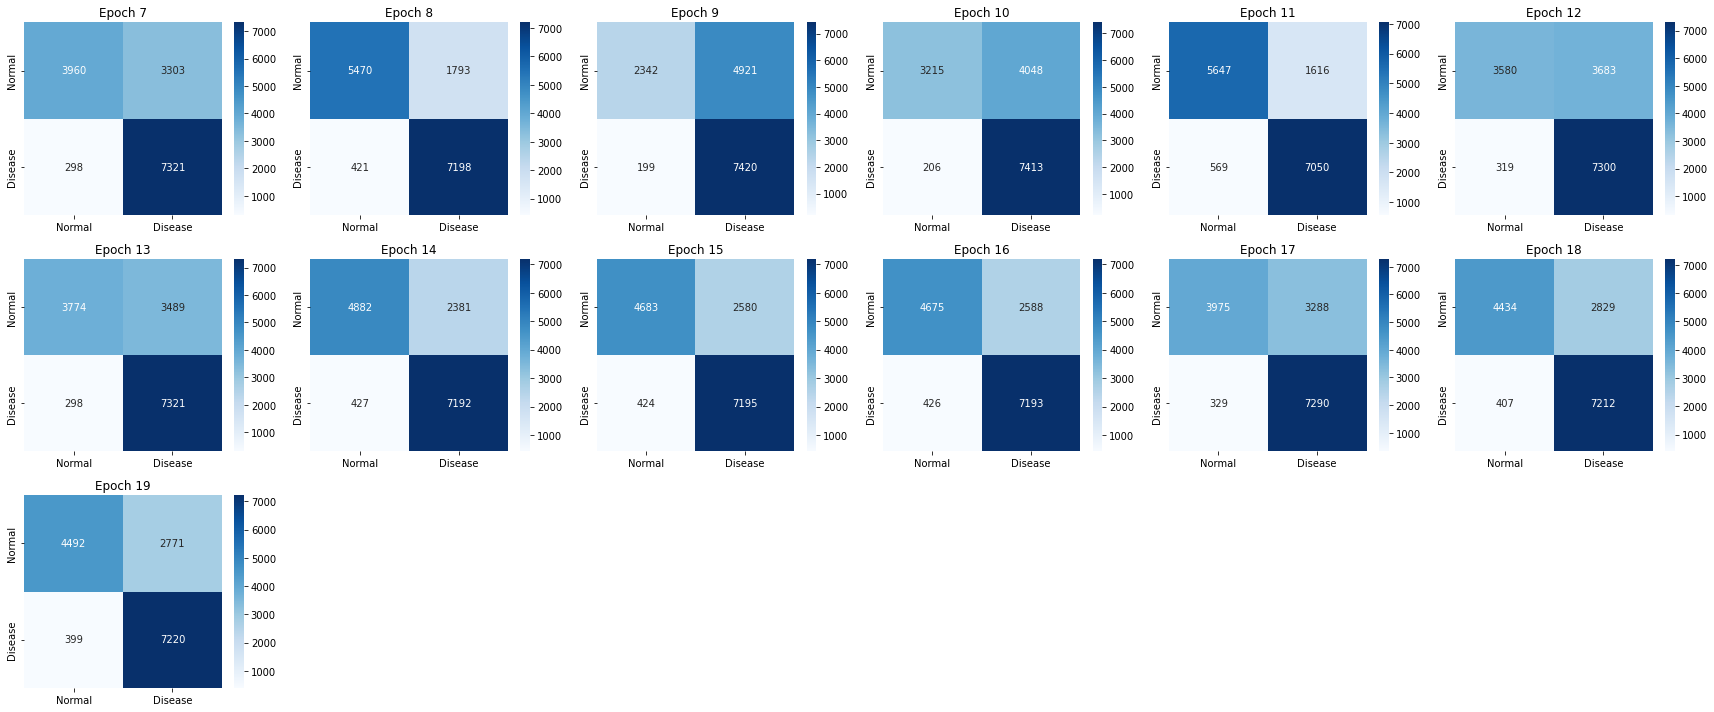

In [2]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import transforms, models   # ✅ FIXED HERE
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score,
    precision_score, recall_score, confusion_matrix
)
from PIL import Image
from tqdm import tqdm


# ============================
# Model
# ============================
class ResNet34GradAug(nn.Module):
    def __init__(self, num_classes=2, pretrained=False):
        super().__init__()
        base = models.resnet34(pretrained=pretrained)

        self.conv1 = base.conv1
        self.bn1 = base.bn1
        self.relu = base.relu
        self.maxpool = base.maxpool

        self.layer1 = base.layer1
        self.layer2 = base.layer2
        self.layer3 = base.layer3
        self.layer4 = base.layer4

        self.avgpool = base.avgpool
        self.fc = nn.Linear(512, num_classes)

    def forward_full(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


# ============================
# Dataset
# ============================
class UCSDDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["new_file_path"]).convert("RGB")
        label = int(row["binary_label"])
        img = self.transform(img)
        return img, label


# ============================
# Config
# ============================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 512
BATCH_SIZE = 32

BASE_CKPT_DIR = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/resnet34_neh_binary_5e4_GradAug_NewLR"
TEST_CSV = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/ucsd_split_test_15.csv"

EPOCHS_TO_TEST = range(7, 20)

# ============================
# Transforms
# ============================
test_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ============================
# Data
# ============================
df = pd.read_csv(TEST_CSV)
test_ds = UCSDDataset(df, test_tf)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# ============================
# Model
# ============================
model = ResNet34GradAug(num_classes=2, pretrained=False).to(DEVICE)

# ============================
# Inference
# ============================
all_cms = []
epoch_list = []

for epoch in EPOCHS_TO_TEST:
    print(f"\nEvaluating Epoch {epoch}")

    ckpt = torch.load(f"{BASE_CKPT_DIR}/epoch_{epoch}.pth", map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    all_probs, all_targets = [], []

    with torch.no_grad():
        for imgs, labels in tqdm(test_loader):
            imgs = imgs.to(DEVICE)
            labels = labels.to(DEVICE)

            logits = model.forward_full(imgs)
            probs = torch.softmax(logits, dim=1)

            all_probs.extend(probs[:, 1].cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    all_probs = np.array(all_probs)
    all_targets = np.array(all_targets)

    preds = (all_probs > 0.5).astype(int)

    acc = accuracy_score(all_targets, preds)
    f1 = f1_score(all_targets, preds)
    auc = roc_auc_score(all_targets, all_probs)

    cm = confusion_matrix(all_targets, preds)
    tn, fp, fn, tp = cm.ravel()
    npv = tn / (tn + fn + 1e-8)

    print(f"Epoch {epoch} | Acc={acc:.4f} | F1={f1:.4f} | AUC={auc:.4f} | NPV={npv:.4f}")

    all_cms.append(cm)
    epoch_list.append(epoch)

# ============================
# Plot Confusion Matrices
# ============================
fig, axes = plt.subplots(3, 6, figsize=(24, 10))
axes = axes.flatten()

for i, (cm, ep) in enumerate(zip(all_cms, epoch_list)):
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Normal", "Disease"],
        yticklabels=["Normal", "Disease"],
        ax=axes[i]
    )
    axes[i].set_title(f"Epoch {ep}")

for j in range(len(all_cms), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("resnet34_GradAug_confusions_NEHOnUCSD.png")
plt.show()


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score,
    precision_score, recall_score, confusion_matrix
)
from PIL import Image
from tqdm import tqdm


# ============================
# Model
# ============================
class ResNet34GradAug(nn.Module):
    def __init__(self, num_classes=2, pretrained=False):
        super().__init__()
        base = models.resnet34(pretrained=pretrained)

        self.conv1 = base.conv1
        self.bn1 = base.bn1
        self.relu = base.relu
        self.maxpool = base.maxpool
        self.layer1 = base.layer1
        self.layer2 = base.layer2
        self.layer3 = base.layer3
        self.layer4 = base.layer4
        self.avgpool = base.avgpool
        self.fc = nn.Linear(512, num_classes)

    def forward_full(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


# ============================
# Dataset
# ============================
class UCSDDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["new_file_path"]).convert("RGB")
        label = int(row["binary_label"])
        return self.transform(img), label


# ============================
# Config
# ============================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 512
BATCH_SIZE = 32

CKPT_PATH = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/resnet34_neh_binary_5e4_GradAug_NewLR/epoch_12.pth"
TEST_CSV = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/ucsd_split_test_15.csv"


# ============================
# Data
# ============================
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

df = pd.read_csv(TEST_CSV)
dataset = UCSDDataset(df, transform)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)


# ============================
# Load model
# ============================
model = ResNet34GradAug(num_classes=2).to(DEVICE)
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()


# ============================
# Inference
# ============================
all_probs = []
all_targets = []

with torch.no_grad():
    for imgs, labels in tqdm(loader, desc="Inference"):
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        logits = model.forward_full(imgs)
        probs = torch.softmax(logits, dim=1)

        all_probs.extend(probs[:, 1].cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_targets = np.array(all_targets)
preds = (all_probs > 0.5).astype(int)


# ============================
# Metrics
# ============================

acc = accuracy_score(all_targets, preds)
f1 = f1_score(all_targets, preds, average="macro")
precision = precision_score(all_targets, preds, average="macro")
recall = recall_score(all_targets, preds, average="macro")
auc = roc_auc_score(all_targets, all_probs)

tn, fp, fn, tp = confusion_matrix(all_targets, preds).ravel()
specificity = tn / (tn + fp + 1e-8)
npv = tn / (tn + fn + 1e-8)

# ============================
# Results
# ============================

print("\n===== Epoch 12 Results =====")
print(f"Accuracy     : {acc:.4f}")
print(f"Macro F1     : {f1:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"AUC          : {auc:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"NPV          : {npv:.4f}")


/home/bharath/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/bharath/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Inference: 100%|██████████| 466/466 [02:12<00:00,  3.53it/s]


===== Epoch 12 Results =====
Accuracy     : 0.7311
Macro F1     : 0.7132
Precision    : 0.7914
Recall       : 0.7255
AUC          : 0.9292
Specificity  : 0.4929
NPV          : 0.9182


In [2]:
import cv2
import matplotlib.pyplot as plt

def get_stats(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    return img.mean(), img.std()

# Pick one image from each
ucsd_sample = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/ZhangLabData/CellData/OCT/test/NORMAL/NORMAL-7843895-2.jpeg"
neh_sample = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/Dataset_3x50_Final/Normal/NORMAL (16)/Image (1).TIFF"

u_mean, u_std = get_stats(ucsd_sample)
n_mean, n_std = get_stats(neh_sample)

print(f"UCSD Mean: {u_mean:.2f}, Std: {u_std:.2f}")
print(f"NEH  Mean: {n_mean:.2f}, Std: {n_std:.2f}")

UCSD Mean: 41.79, Std: 41.26
NEH  Mean: 41.25, Std: 43.37


/home/bharath/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Metric     | UCSD            | NEH            
---------------------------------------------
Format     | JPEG            | TIFF           
Mode       | L               | L              
Min        | 0               | 0              
Max        | 255             | 255            
Mean       | 53.27           | 29.97          
Std        | 54.50           | 38.28          
Shape      | (496, 1024)     | (512, 496)     


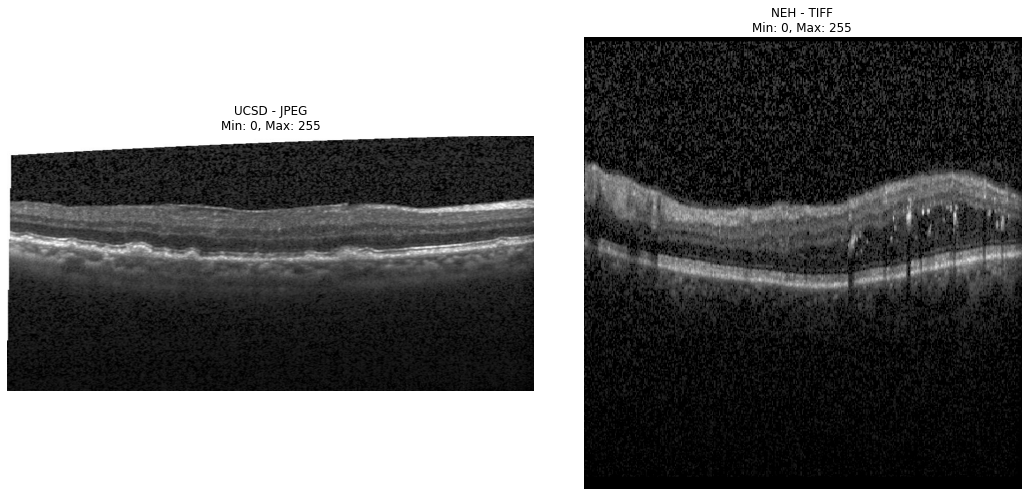

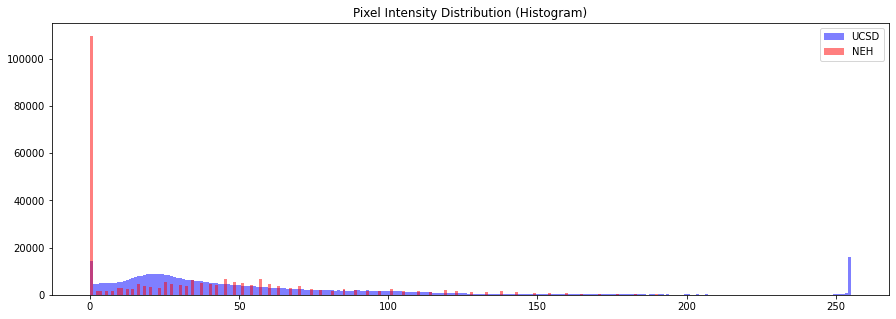

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Paths to your samples
ucsd_path = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/ZhangLabData/CellData/OCT/test/DRUSEN/DRUSEN-552984-1.jpeg"
neh_path = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/Dataset_3x50_Final/DME/DME (10)/Image (48).TIFF"

def analyze_image(path, name):
    # Use PIL to open to see raw format details
    pil_img = Image.open(path)
    # Convert to numpy for stats
    img_np = np.array(pil_img.convert('L')) # Convert to Grayscale
    
    stats = {
        "Name": name,
        "Format": pil_img.format,
        "Mode": pil_img.mode,
        "Min": np.min(img_np),
        "Max": np.max(img_np),
        "Mean": np.mean(img_np),
        "Std": np.std(img_np),
        "Shape": img_np.shape
    }
    return img_np, stats

# Get data
img_u, stats_u = analyze_image(ucsd_path, "UCSD (JPEG)")
img_n, stats_n = analyze_image(neh_path, "NEH (TIFF)")

# Print Stats Table
print(f"{'Metric':<10} | {'UCSD':<15} | {'NEH':<15}")
print("-" * 45)
for key in ["Format", "Mode", "Min", "Max", "Mean", "Std", "Shape"]:
    val_u = f"{stats_u[key]:.2f}" if isinstance(stats_u[key], float) else str(stats_u[key])
    val_n = f"{stats_n[key]:.2f}" if isinstance(stats_n[key], float) else str(stats_n[key])
    print(f"{key:<10} | {val_u:<15} | {val_n:<15}")

# Visualization
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(img_u, cmap='gray')
plt.title(f"UCSD - {stats_u['Format']}\nMin: {stats_u['Min']}, Max: {stats_u['Max']}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_n, cmap='gray')
plt.title(f"NEH - {stats_n['Format']}\nMin: {stats_n['Min']}, Max: {stats_n['Max']}")
plt.axis('off')

plt.tight_layout()
plt.show()

# Optional: Plot Histograms to see the distribution shape
plt.figure(figsize=(15, 5))
plt.hist(img_u.ravel(), bins=256, range=(0, 255), alpha=0.5, label='UCSD', color='blue')
plt.hist(img_n.ravel(), bins=256, range=(0, 255), alpha=0.5, label='NEH', color='red')
plt.title("Pixel Intensity Distribution (Histogram)")
plt.legend()
plt.show()

In [5]:
import pandas as pd

df_ucsd = pd.read_csv("/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD_2/dhu_filtered.csv")
df_ucsd['image_shape'].value_counts()

# image_shape
# 496x512    58037
# 496x768    29749
# 512x512     8659
# Name: count, dtype: int64

# image_shape
# 496x512     58037
# 496x768     29749
# 496x1536    11512
# 512x512      8659
# 496x1024     1329
# 496x384        21
# 455x900         1
# 277x642         1
# Name: count, dtype: int64

image_shape
496x512    2346
496x768     519
Name: count, dtype: int64

In [1]:
import pandas as pd
from PIL import Image
from tqdm import tqdm
import os

# ===============================
# CONFIG
# ===============================
CSV_PATH = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/ucsd.csv"

# ===============================
# LOAD CSV
# ===============================
df = pd.read_csv(CSV_PATH)

print(f"Loaded {len(df)} rows")

# ===============================
# FUNCTION TO GET IMAGE SHAPE
# ===============================
def get_image_shape(path):
    try:
        with Image.open(path) as img:
            w, h = img.size
            return f"{h}x{w}"   # Height x Width
    except Exception as e:
        return "READ_ERROR"

# ===============================
# PROCESS IMAGES
# ===============================
tqdm.pandas(desc="Reading images")

df["image_shape"] = df["new_file_path"].progress_apply(get_image_shape)

# ===============================
# SAVE BACK TO SAME CSV
# ===============================
# df.to_csv(CSV_PATH, index=False)
print("✅ CSV updated successfully")

# ===============================
# STATS
# ===============================
shape_counts = df["image_shape"].value_counts()
shape_percent = (shape_counts / len(df)) * 100

print("\n🔹 Unique image shapes:", len(shape_counts))
print("\n🔹 Shape distribution:\n")

for shape, count in shape_counts.items():
    print(f"{shape:12s} : {count:6d} images ({shape_percent[shape]:.2f}%)")


Loaded 109309 rows


Reading images: 100%|██████████| 109309/109309 [21:04<00:00, 86.45it/s] 

✅ CSV updated successfully

🔹 Unique image shapes: 8

🔹 Shape distribution:

496x512      :  58037 images (53.09%)
496x768      :  29749 images (27.22%)
496x1536     :  11512 images (10.53%)
512x512      :   8659 images (7.92%)
496x1024     :   1329 images (1.22%)
496x384      :     21 images (0.02%)
455x900      :      1 images (0.00%)
277x642      :      1 images (0.00%)


In [6]:
import pandas as pd
from PIL import Image
from tqdm import tqdm
import os

# ===============================
# CONFIG
# ===============================
FILE_PATHS = [
    "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD_2/neh_train_reduced.csv",
    "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD_2/neh_val_reduced.csv",
    "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD_2/neh_test_reduced.csv"
]

# ===============================
# LOAD AND CONCATENATE
# ===============================
print("📂 Loading and merging files...")
df_list = [pd.read_csv(f) for f in FILE_PATHS]
df = pd.concat(df_list, ignore_index=True)

df['binary_label'].value_counts()

# print(f"✅ Total rows loaded: {len(df)}")

# # ===============================
# # FUNCTION TO GET IMAGE SHAPE
# # ===============================
# def get_image_shape(path):
#     try:
#         # Using Image.open is efficient because it only reads the header
#         with Image.open(path) as img:
#             w, h = img.size
#             return f"{h}x{w}"   # Height x Width
#     except Exception:
#         return "READ_ERROR"

# # ===============================
# # PROCESS IMAGES
# # ===============================
# tqdm.pandas(desc="Reading images")

# # Assuming 'new_file_path' is the column name in all three CSVs
# df["image_shape"] = df["new_file_path"].progress_apply(get_image_shape)

# # ===============================
# # STATS
# # ===============================
# shape_counts = df["image_shape"].value_counts()
# shape_percent = (shape_counts / len(df)) * 100

# print("\n" + "="*30)
# print("📊 FINAL SHAPE DISTRIBUTION")
# print("="*30)
# print(f"🔹 Unique image shapes: {len(shape_counts)}")
# print("-" * 30)

# for shape, count in shape_counts.items():
#     print(f"{shape:12s} : {count:6d} images ({shape_percent[shape]:.2f}%)")

# ==============================
# 📊 FINAL SHAPE DISTRIBUTION
# ==============================
# 🔹 Unique image shapes: 2
# ------------------------------
# 512x496      :   2701 images (89.82%)
# 496x512      :    306 images (10.18%)

📂 Loading and merging files...


binary_label
0    1585
1    1422
Name: count, dtype: int64

In [1]:
import pandas as pd
df = pd.read_csv("/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD_2/octC8_filtered.csv")
df.head()


,split,label_text,new_file_path,binary_label,shape
0,train,AMD,/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...,1,512x1000
1,train,AMD,/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...,1,512x1000
2,train,AMD,/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...,1,512x1000
3,train,AMD,/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...,1,512x1000
4,val,AMD,/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...,1,512x1000


In [3]:
df.head()

,split,new_file_path,label_text,four_class_label,binary_label,image_shape
0,train,/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...,NORMAL,0,0,496x768
1,train,/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...,NORMAL,0,0,496x512
2,train,/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...,NORMAL,0,0,496x512
3,train,/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...,NORMAL,0,0,496x768
4,train,/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...,NORMAL,0,0,496x512


In [4]:
import pandas as pd

# ===============================
# PATHS
# ===============================
INPUT_CSV = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/ucsd.csv"
OUTPUT_CSV = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/ucsd_filtered.csv"

# ===============================
# LOAD
# ===============================
df = pd.read_csv(INPUT_CSV)

print("Original rows:", len(df))
print("\nOriginal shape distribution:")
print(df["image_shape"].value_counts())

# ===============================
# FILTER
# ===============================
keep_shapes = ["496x512", "496x768", "512x512"]

df_filtered = df[df["image_shape"].isin(keep_shapes)].reset_index(drop=True)

# ===============================
# SAVE
# ===============================
df_filtered.to_csv(OUTPUT_CSV, index=False)

# ===============================
# STATS
# ===============================
print("\nAfter filtering:")
print("Remaining rows:", len(df_filtered))
print("\nNew shape distribution:")
print(df_filtered["image_shape"].value_counts())


Original rows: 109309

Original shape distribution:
image_shape
496x512     58037
496x768     29749
496x1536    11512
512x512      8659
496x1024     1329
496x384        21
455x900         1
277x642         1
Name: count, dtype: int64

After filtering:
Remaining rows: 96445

New shape distribution:
image_shape
496x512    58037
496x768    29749
512x512     8659
Name: count, dtype: int64


In [5]:
import numpy as np
import pandas as pd
from pathlib import Path

# ===============================
# CONFIG
# ===============================
CSV_PATH = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/ucsd_filtered.csv"

OUT_TRAIN = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/ucsd_filtered_split_train_70.csv"
OUT_VAL   = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/ucsd_filtered_split_val_15.csv"
OUT_TEST  = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/ucsd_filtered_split_test_15.csv"

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ===============================
# LOAD CSV
# ===============================
df = pd.read_csv(CSV_PATH)

# ===============================
# EXTRACT PATIENT ID
# ===============================
def extract_patient_id(path):
    fname = Path(path).name
    return fname.replace(".jpeg", "").split("-")[1]

df["patient_id"] = df["new_file_path"].apply(extract_patient_id)

# ===============================
# SPLIT BY PATIENT
# ===============================
unique_patients = df["patient_id"].unique()
np.random.shuffle(unique_patients)

n_total = len(unique_patients)
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)

train_patients = set(unique_patients[:n_train])
val_patients   = set(unique_patients[n_train:n_train + n_val])
test_patients  = set(unique_patients[n_train + n_val:])

# ===============================
# CREATE SPLITS
# ===============================
train_df = df[df["patient_id"].isin(train_patients)].copy()
val_df   = df[df["patient_id"].isin(val_patients)].copy()
test_df  = df[df["patient_id"].isin(test_patients)].copy()

# ===============================
# VERIFY NO LEAKAGE
# ===============================
print("Patient overlap check (must be 0):")
print("Train ∩ Val :", len(set(train_df.patient_id) & set(val_df.patient_id)))
print("Train ∩ Test:", len(set(train_df.patient_id) & set(test_df.patient_id)))
print("Val ∩ Test  :", len(set(val_df.patient_id) & set(test_df.patient_id)))

# ===============================
# STATS
# ===============================
print("\nImage counts:")
print(f"Train: {len(train_df)}")
print(f"Val  : {len(val_df)}")
print(f"Test : {len(test_df)}")

print("\nPatient counts:")
print(f"Train: {train_df.patient_id.nunique()}")
print(f"Val  : {val_df.patient_id.nunique()}")
print(f"Test : {test_df.patient_id.nunique()}")

# ===============================
# SAVE
# ===============================
train_df.to_csv(OUT_TRAIN, index=False)
val_df.to_csv(OUT_VAL, index=False)
test_df.to_csv(OUT_TEST, index=False)

print("\n✅ Files saved:")
print(OUT_TRAIN)
print(OUT_VAL)
print(OUT_TEST)


Patient overlap check (must be 0):
Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0

Image counts:
Train: 68412
Val  : 14141
Test : 13892

Patient counts:
Train: 3323
Val  : 712
Test : 713

✅ Files saved:
/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/ucsd_filtered_split_train_70.csv
/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/ucsd_filtered_split_val_15.csv
/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/ucsd_filtered_split_test_15.csv
